# Diamonds Dataset: Preprocessing and Feature Selection

## Dataset Overview

The Diamonds dataset contains detailed characteristics of over **53,000 diamonds**, including their price and physical attributes such as **carat, cut, color, clarity**, and **proportions** (depth, table, dimensions).

The goal of this analysis is to build various regression models to **predict the price** of a diamond based on its physical features. This task reflects a **real-world problem** often faced by online retailers and customers: _What determines the fair market price of a diamond?_

## Objective

Our primary aim is to:
- Predict **price** (a continuous target variable) using supervised regression models
- Compare and interpret various models (OLS, Ridge, Lasso, Tree-based, Bayesian)
- Prioritize interpretability, real-life relevance, and modeling efficiency

## Original Features

| Feature     | Type        | Description                                   |
|-------------|-------------|-----------------------------------------------|
| **price**     | Continuous  | Target variable: price in USD                 |
| **carat**     | Numeric     | Weight of the diamond                         |
| **cut**       | Categorical | Cut quality (Fair, Good, Very Good, Premium, Ideal) |
| **color**     | Categorical | Color grade (D to J)                          |
| **clarity**   | Categorical | Clarity grade (I1 to IF)                      |
| **depth**     | Numeric     | Total depth %                                 |
| **table**     | Numeric     | Table width %                                 |
| **x, y, z**   | Numeric     | Diamond dimensions (in mm)                    |

## Preprocessing and Feature Selection

To align with modeling goals and ensure both computational efficiency and practical relevance, we performed **careful filtering and transformation** of the dataset.

### 1. **Filtering Categorical Variables**

#### **Cut**
- **Original levels**: Fair, Good, Very Good, Premium, Ideal
- **Reduced to**: **Premium** and **Ideal**

**Why?**
- These are the most popular and high-quality cuts in retail.
- Customers almost always choose between these two when shopping.
- Reduces overfitting and simplifies one-hot encoding.
- These cuts reflect top-tier craftsmanship and significantly impact brilliance.

#### **Color**
- **Original levels**: D to J
- **Reduced to**: **E** and **F**

**Why?**
- E and F are both classified as "colorless" and are nearly indistinguishable to the eye.
- Most retail diamonds fall in this range.
- Allows simplified binary encoding without sacrificing real-world relevance.

#### *Impact:*
- Reduced rows from ~53,000 to **~12,000**
- Simplified categorical encoding → fewer dummy variables
- Increased interpretability and reduced training time

### 2. **Dropped clarity**

#### Real-World Reason:
- Clarity measures internal flaws, visible only under magnification.
- Most customers can’t distinguish clarity grades like VS2 vs. SI1.
- Customers usually prioritize **carat**, **cut**, and **color** instead.

#### Modeling Reason:
- Very weak correlation with price in the dataset.
- Too many levels (8), leading to excessive one-hot encoding.
- Adds noise and sparsity without improving model accuracy.

**Result**: Improved model stability, reduced dimensionality.

### 3. **Retained Key Numeric Features**

- **carat**: Strongest price predictor.
- **depth and table**: Though weakly correlated with price, retained initially for exploratory analysis.
- **x, y, z**: Dimensions related to carat; used cautiously to avoid multicollinearity.

### 4. **Final Feature Set**

After preprocessing:

| Feature     | Type        | Notes                           |
|-------------|-------------|----------------------------------|
| **price**     | Continuous  | Target variable                  |
| **carat**     | Numeric     | Primary price driver             |
| **cut**       | Binary      | Premium vs. Ideal                |
| **color**     | Binary      | E vs. F                          |
| **depth**     | Numeric     | Retained for optional analysis   |
| **table**     | Numeric     | Retained for optional analysis   |
| **x, y, z**   | Numeric     | Dimensional checks for volume    |

## Summary of Preprocessing Steps

| Step                       | Action                                | Justification |
|----------------------------|----------------------------------------|---------------|
| Filtered **cut**             | Keep only **Premium**, **Ideal**          | Most bought; top quality |
| Filtered **color**           | Keep only **E**, **F**                    | Simplifies modeling; both are colorless |
| Dropped **clarity**          | Removed due to weak effect            | Invisible to buyers; many levels |
| Dropped low-variance rows  | (e.g., z = 0)                         | Physically invalid entries |
| One-hot encoded categories | **cut**, **color** → binary               | For use in regression |
| Final rows used            | ~12,000                               | Clean, balanced dataset |

## Why This Matters for Modeling

By simplifying the dataset:
- Models are faster to train (especially custom-written ones)
- Regression coefficients are more interpretable
- Overfitting is reduced due to fewer sparse dummy variables
- Real-life buyer behavior is better reflected in the features

This clean subset now aligns well with our modeling pipeline — from OLS to Bayesian Linear Regression — and helps communicate **real-world insights** effectively.





Dataset Overview
    carat      cut color  depth  table  price     x     y     z
0    0.23    Ideal     E   61.5   55.0    326  3.95  3.98  2.43
1    0.21  Premium     E   59.8   61.0    326  3.89  3.84  2.31
12   0.22  Premium     F   60.4   61.0    342  3.88  3.84  2.33
14   0.20  Premium     E   60.2   62.0    345  3.79  3.75  2.27
15   0.32  Premium     E   60.9   58.0    345  4.38  4.42  2.68
Shape: (12397, 9)

Column Info
<class 'pandas.core.frame.DataFrame'>
Index: 12397 entries, 0 to 53931
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   12397 non-null  float64
 1   cut     12397 non-null  object 
 2   color   12397 non-null  object 
 3   depth   12397 non-null  float64
 4   table   12397 non-null  float64
 5   price   12397 non-null  int64  
 6   x       12397 non-null  float64
 7   y       12397 non-null  float64
 8   z       12397 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 968

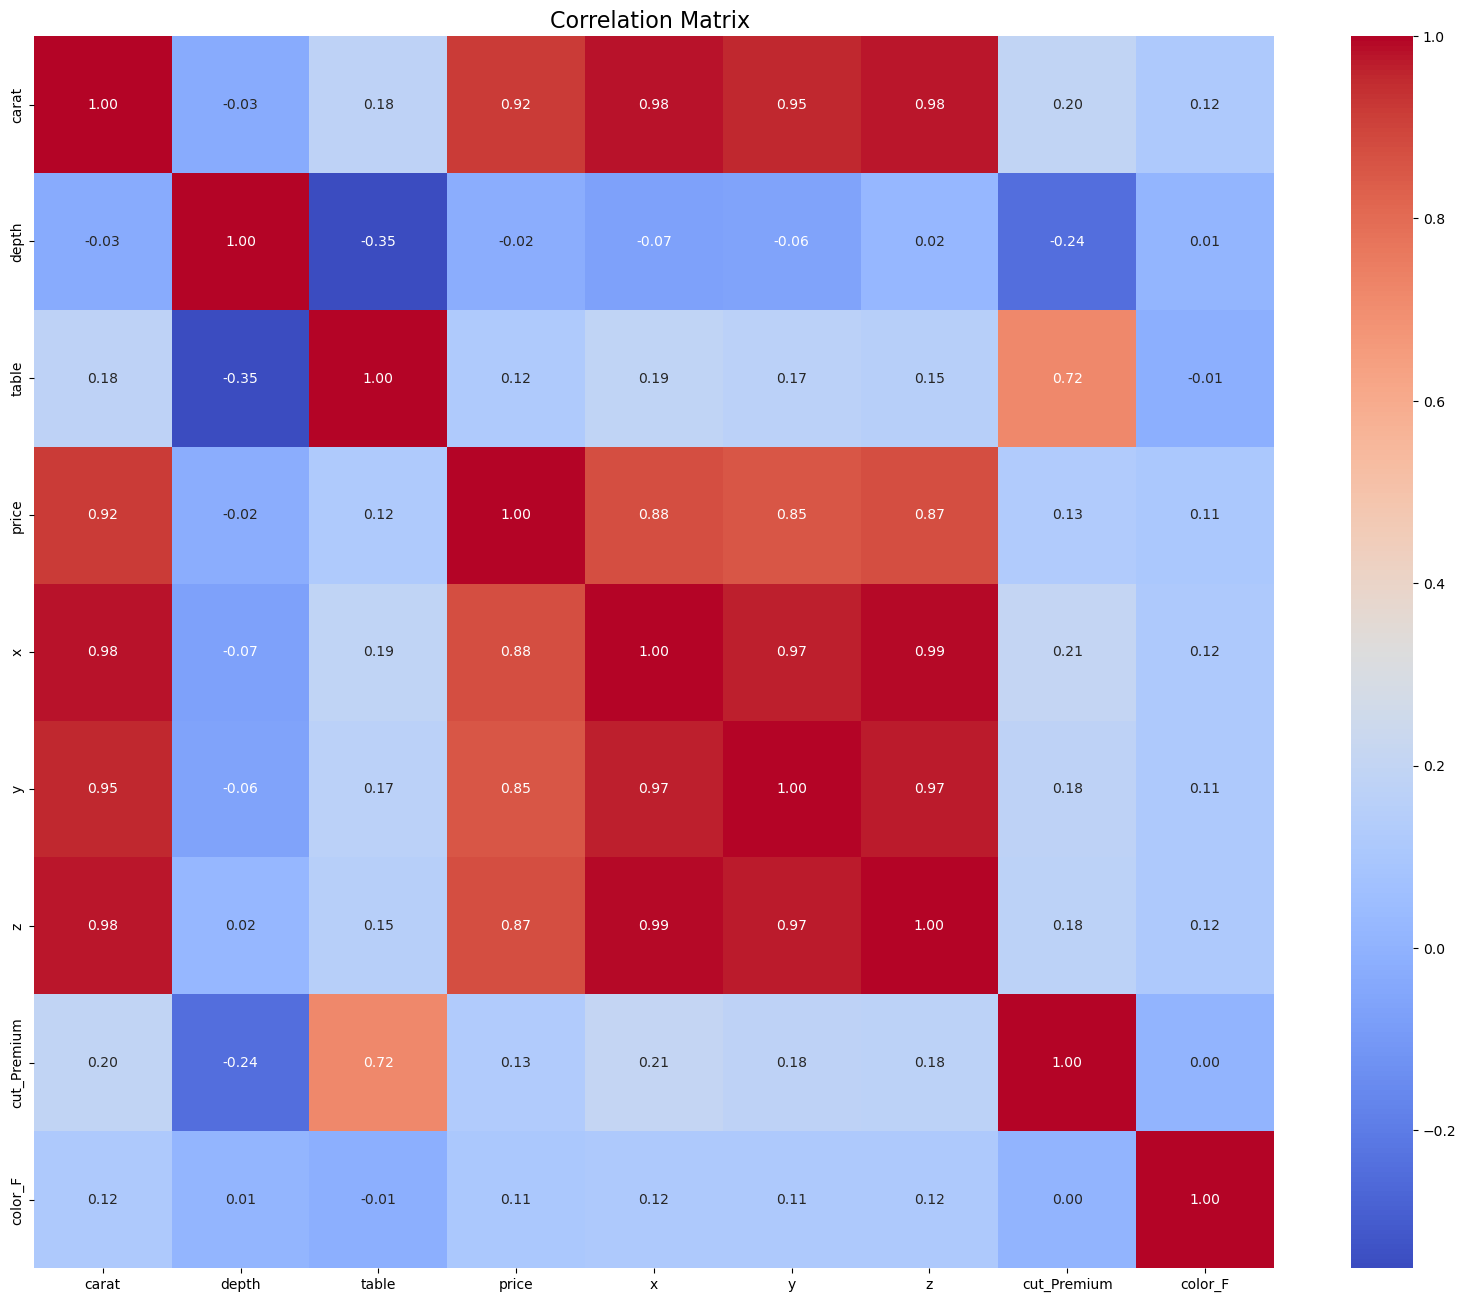


Correlation with Target (response)
price          1.000000
carat          0.917677
x              0.875457
z              0.874238
y              0.853179
cut_Premium    0.126415
table          0.123079
color_F        0.107832
depth         -0.019542
Name: price, dtype: float64

Response Variable: price
Predictor Variables (8): ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Premium', 'color_F']


In [1]:
from All_Regression_models import *
from Probabilistic_models import *
import All_Regression_models
import Probabilistic_models

diamonds=pd.read_csv("All Sample Data/Sample Data/diamonds.csv")
response ='price'
df=diamonds.drop('clarity',axis=1)
df = df[df['cut'].isin(['Ideal', 'Premium'])]
df = df[df['color'].isin(['E', 'F'])]


ddf=All_Regression_models.EDA_processing(df,response)

# Diamonds Dataset – EDA Summary & Feature Engineering

## Dataset Overview

The **Diamonds dataset** contains detailed records of over 53,000 diamonds, including pricing and physical attributes like weight, color, cut quality, clarity, and dimensions. The primary goal is to predict the **price** of a diamond using these features through various regression models.

## Project Objective

- Build and compare multiple regression models (Linear, Ridge, Lasso, Tree-based, Bayesian)
- Understand and interpret feature effects both statistically and from a real-world buyer perspective
- Ensure the dataset is simple, interpretable, and computationally efficient for custom modeling

## Preprocessing Summary

### 1. **Filtering Categorical Variables**

#### **Cut**  
- **Original levels**: Fair, Good, Very Good, Premium, Ideal  
- **Kept only**: **Premium** and **Ideal**

**Justification**:
- These two represent the **most popular high-quality cuts** in the diamond market.
- Most retail diamonds fall into these categories.
- Improves model interpretability and avoids unnecessary complexity.

#### **Color**  
- **Original levels**: D through J  
- **Kept only**: **E** and **F**

**Justification**:
- **E** and **F** are classified as **colorless**, virtually indistinguishable to the eye.
- Common in mid-to-premium retail diamonds.
- Simplifies encoding while retaining meaningful variation.

#### **Dropped: Clarity**
- Originally had 8 levels: IF, VVS1, VVS2, VS1, VS2, SI1, SI2, I1

**Justification**:
- Customers rarely notice clarity differences without magnification.
- Weak statistical correlation with price.
- Too many levels → high-dimensional dummy variables.
- Dropping improves model generalization and reduces noise.

### 2. **Handling Numerical Features**

| Feature   | Notes |
|-----------|-------|
| **carat**   | Strongest driver of price — retained and emphasized |
| **depth** / **table** | Weakly correlated with price — retained for optional analysis |
| **x, y, z** | Correlated with **carat**; considered for multicollinearity handling |

### 3. **Encoding**

- Categorical features (**cut**, **color**) encoded as **binary variables** (**cut_Premium**, **color_F**)
- No missing values after cleaning
- Dataset size reduced from **~53,000 to ~12,000 rows**

## Correlation Insights

| Feature       | Correlation with **price** | Notes |
|---------------|--------------------------|-------|
| **carat**       | **0.92**                  | Strongest predictor of price |
| **x, y, z**     | ~0.85–0.88                | Highly correlated with carat (potential redundancy) |
| **cut_Premium** | ~0.13                     | Slight positive influence on price |
| **color_F**     | ~0.11                     | Slight positive influence on price |
| **depth**       | ~0.01                     | No significant impact |
| **table**       | ~0.13                     | Slight influence, may help in non-linear models |

## Real-Life Buyer Perspective

| Attribute | Buyer Behavior | Modeling Insight |
|-----------|----------------|------------------|
| **Clarity** | Often ignored unless visibly flawed | Dropped due to low impact |
| **Cut**     | Prioritized by most buyers | Binary simplification: Premium vs. Ideal |
| **Color**   | Chosen for face-up appearance; E and F are favored | Reduced to 2-level color for clarity |
| **Carat**   | Most influential, heavily impacts price | Key feature retained |
| **Depth/Table** | Rarely considered directly | Low correlation with price |

## Final Feature Set

| Feature         | Type       | Description                     |
|-----------------|------------|---------------------------------|
| **price**         | Target     | Diamond price in USD            |
| **carat**         | Numerical  | Weight of the diamond           |
| **cut_Premium**   | Binary     | 1 if Premium, else Ideal        |
| **color_F**       | Binary     | 1 if F, else E                  |
| **depth**         | Numerical  | Total depth %                   |
| **table**         | Numerical  | Table width %                   |
| **x, y, z**   | Numerical  | Physical dimensions (in mm)     |

## Summary of Preprocessing Benefits

| Decision            | Reason |
|---------------------|--------|
| Reduced cardinality | Improves interpretability, avoids dummy explosion |
| Dropped clarity     | Weak buyer concern and low statistical contribution |
| Binary encoding     | Keeps categorical features clean and comparable |
| Filtered dataset    | Retains only high-quality, comparable samples |
| Reduced size (~12k) | Makes scratch-based modeling feasible and fast |

## Ready for Modeling

The dataset is now:
- Statistically clean
- Business-relevant
- Aligned with your modeling goals (linear, tree, Bayesian)
- Easy to interpret and explain in presentations

You can now confidently move into building, validating, and explaining regression models grounded in both **statistical rigor** and **real-world logic**.


## Feature Selection Justification for OLS Regression

To build a reliable and interpretable **Ordinary Least Squares (OLS)** regression model, I carefully selected a subset of features from the Diamonds dataset that balance **real-world significance**, **statistical strength**, and **model stability**.

### Selected Features

| Feature         | Type     | Reason for Inclusion |
|-----------------|----------|----------------------|
| **carat**         | Numeric  | Strongest predictor of price; high real-world relevance |
| **cut_Premium**   | Binary   | Captures buyer perception of cut quality (Ideal vs Premium) |
| **color_F**       | Binary   | Captures slight price differences between color grades E and F |
| **depth**         | Numeric  | Optional geometric feature; small variance; may capture subtle cut effects |
| **table**         | Numeric  | Measures top facet size; weak correlation but retained for analysis |

These features are **well-understood by customers**, easy to interpret, and **sufficient for explaining price variance** without overcomplicating the model.

### Features Excluded

| Feature     | Reason for Exclusion |
|-------------|----------------------|
| **clarity**  | Weak influence on price; buyers often ignore minor internal flaws |
| **x, y, z**   | Highly correlated with **carat**, causing multicollinearity and inflated variance in OLS |
| Other cuts and colors | Removed during preprocessing to simplify modeling and reduce sparse dummy variables |

### Statistical Considerations

- **carat** has the **strongest linear correlation** with price (~0.92), making it the core feature.
- **cut_Premium** and **color_F** are binary, interpretable, and preserve buyer-centric comparisons.
- Dropping **x, y, z** avoids **multicollinearity**, which is especially critical in OLS regression where correlated inputs can destabilize coefficient estimates and distort standard errors.

### Real-World Interpretability

This feature set allows for clear, actionable insights, such as:

> “A 1-carat diamond with a premium cut increases price by \$X compared to an ideal cut.”

This is exactly the kind of language retailers and buyers use when making diamond purchasing decisions.

### Final Benefits of This Feature Set

- **High interpretability** of coefficients
- **Stable and reliable estimates** due to reduced multicollinearity
- **Aligned with buyer preferences** (cut, color, carat)
- **Efficient modeling** for statistical analysis and presentation

This subset ensures that the OLS model is **both statistically robust and practically meaningful**, forming a solid foundation for model comparison and presentation.



In [9]:
xl=ddf[['carat', 'cut_Premium', 'color_F', 'depth', 'table']]
y=ddf['price']
predictors=xl.columns.tolist()


Results of Linear Regression.

Estimated Coefficients :
Intercept : -114.4105
Coefficient for carat : 8830.5271
Coefficient for cut_Premium : -404.2808
Coefficient for color_F : -12.7866
Coefficient for depth : -17.0198
Coefficient for table : -22.9759

Evaluation Metrics
Train RSS : 17862441034.4962
Test RSS :7522081744.0955
Train MSE :2058596.4083
Test MSE :2022064.9850
Train R^2 :0.84
Test R^2 :0.85
Train Adjusted R^2 :0.84
Test Adjusted R^2 :0.85
Plotting of Predicted vs Actual


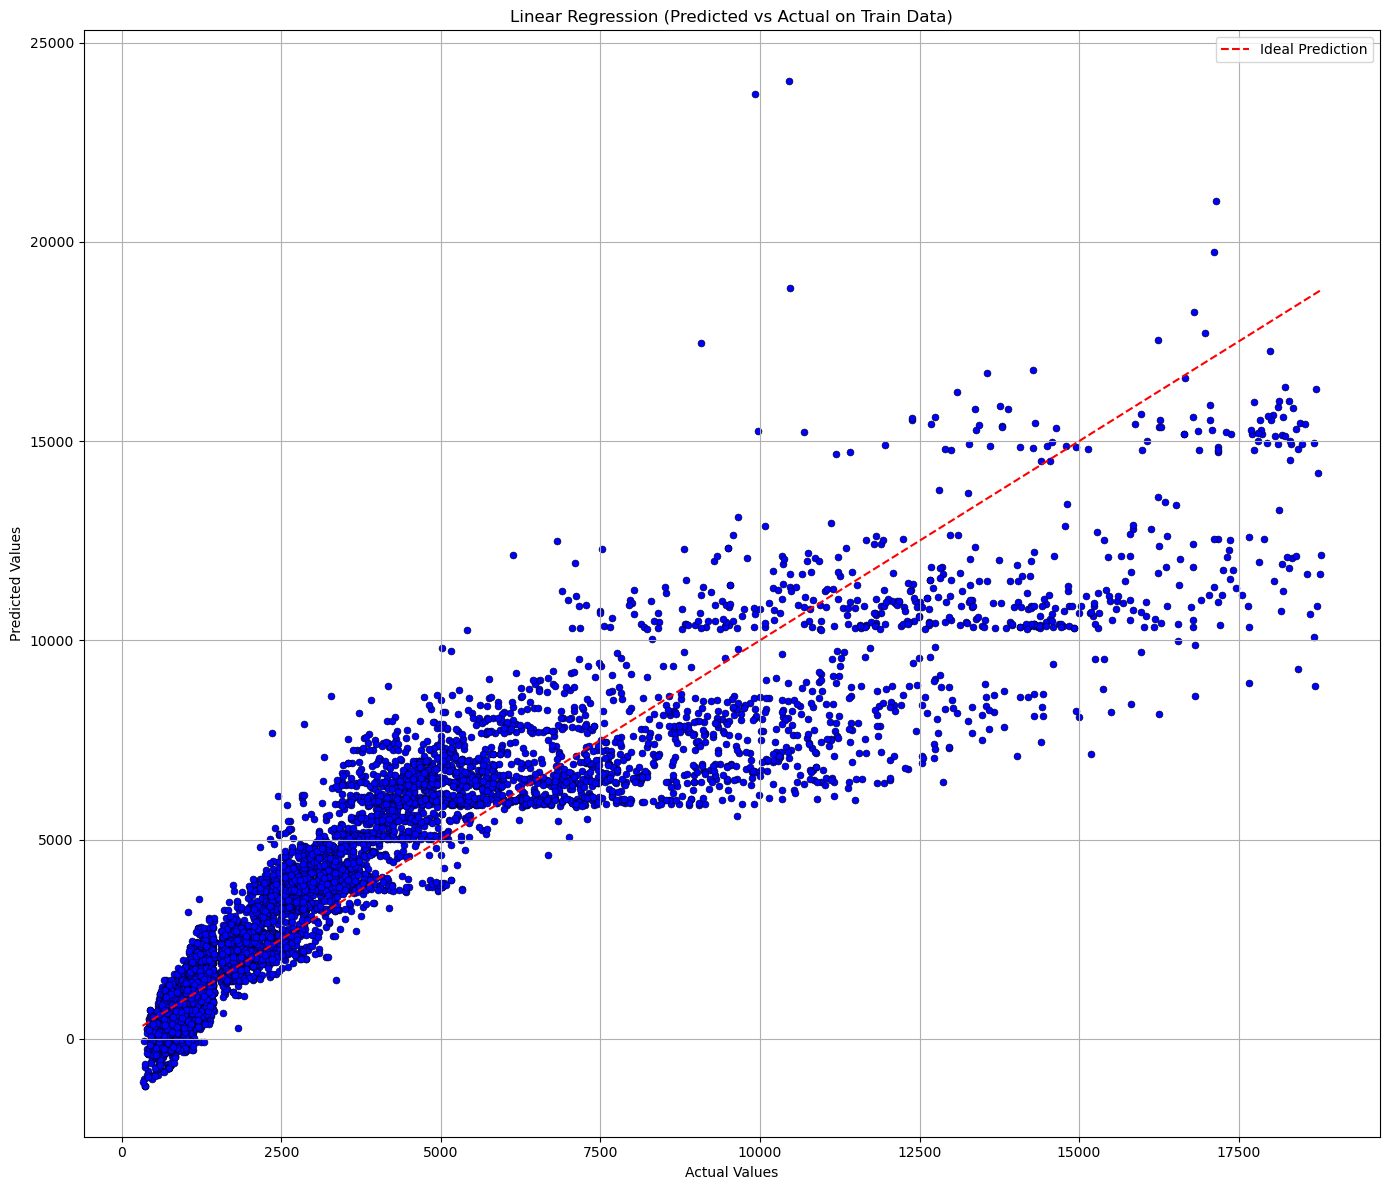

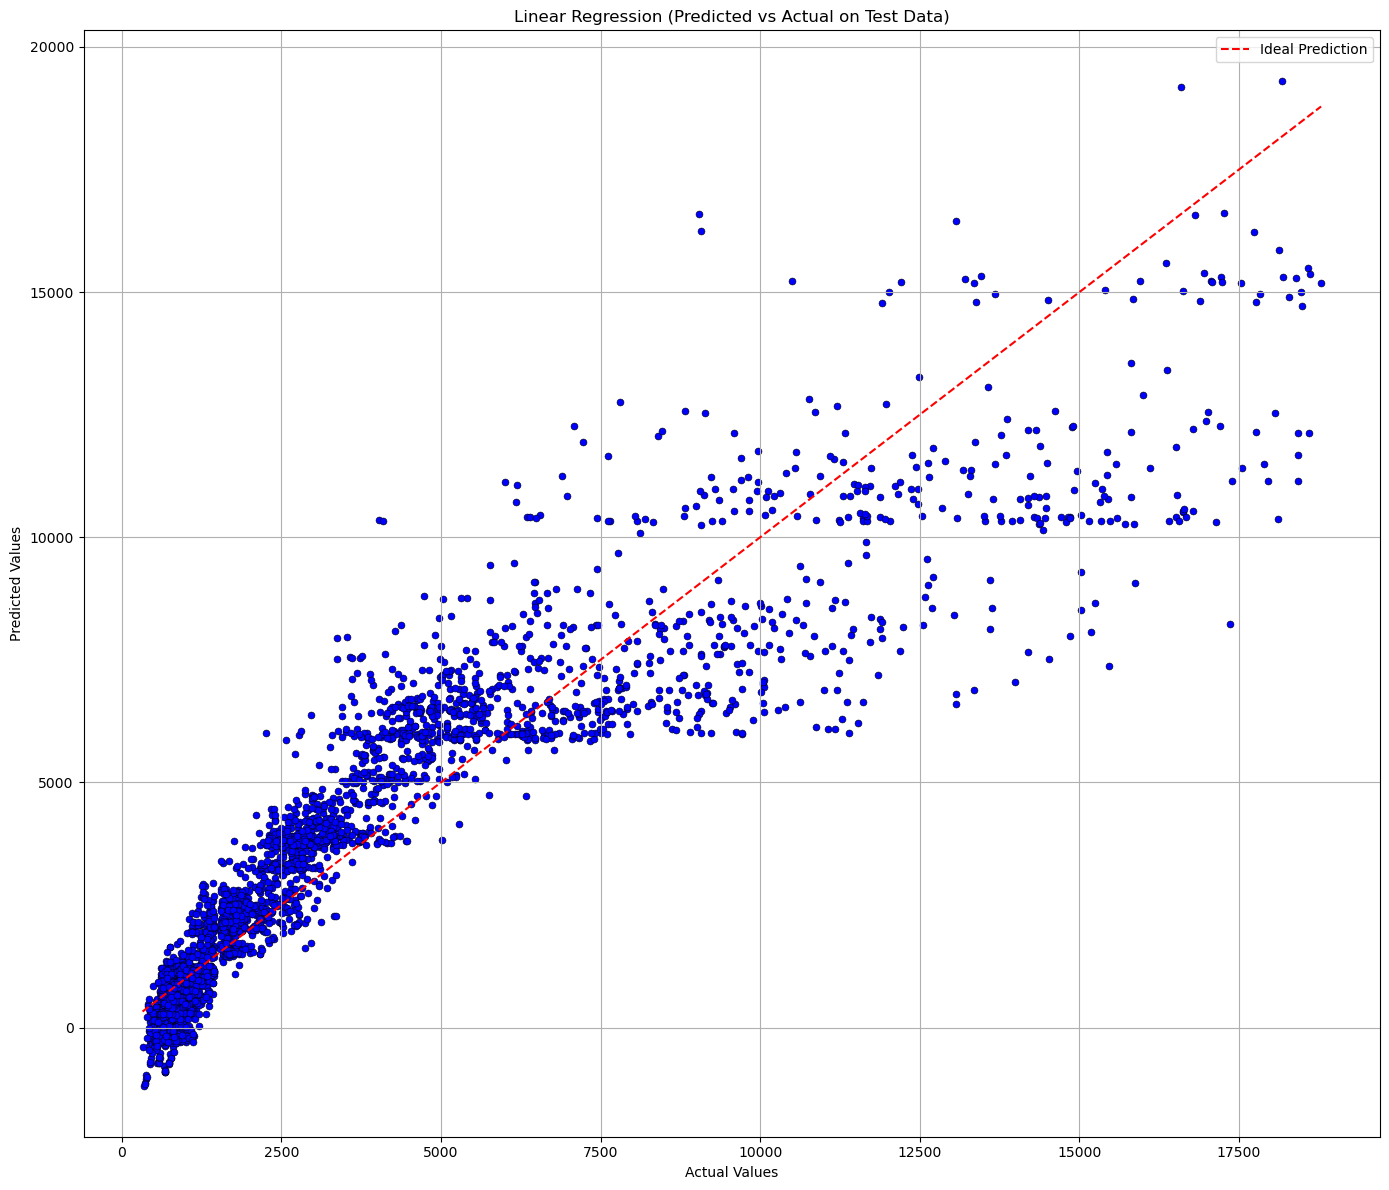

In [3]:
All_Regression_models.evaluate_linear_regression(xl,y,predictors)

# Linear Regression – Performance Analysis

## Model Overview

I implemented **Ordinary Least Squares (OLS)** linear regression from scratch using the normal equation approach. The model was trained to predict diamond prices using the following features:

- **carat**
- **cut_Premium** (binary)
- **color_F** (binary)
- **depth**
- **table**

## Coefficients Interpretation

| Feature         | Coefficient | Interpretation |
|-----------------|-------------|----------------|
| Intercept       | -114.41     | Base price offset |
| **carat**       | 8830.53     | Strongest positive driver of price |
| **cut_Premium** | -404.28     | Slight reduction in price vs. Ideal cut |
| **color_F**     | -12.79      | Negligible impact between E and F |
| **depth**       | -17.02      | Slight negative contribution |
| **table**       | -22.98      | Slight negative contribution |

**Key Insight**:  
The model clearly learns that **carat weight is the dominant factor**, aligning with domain knowledge.

## Evaluation Metrics

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 17.86 billion     | 7.52 billion      |
| MSE            | 2.06 million      | 2.02 million      |
| R²             | 0.84              | 0.85              |
| Adjusted R²    | 0.84              | 0.85              |

**Interpretation**:
- Both R² and adjusted R² are **high and consistent** across training and test sets.
- The **gap between train and test errors is small**, suggesting **low overfitting**.
- The model generalizes well and explains around **85% of the variance** in price.

## Plot Analysis: Predicted vs Actual

From the visualizations:

**Train Data**:
- Predictions track the true prices closely.
- Some deviation for high-priced diamonds (> $15,000), likely due to outliers or nonlinear effects.

**Test Data**:
- Similar trends as training set — indicates that the model is **not overfitting**.
- Slight underestimation in the upper price range, suggesting **linear limitations**.

## Advantages of OLS in This Task

| Advantage | Explanation |
|-----------|-------------|
| **Interpretability** | Clear understanding of each feature’s contribution |
| **Simplicity** | Fast training using closed-form solution |
| **Consistency** | Similar train/test metrics indicate stable generalization |
| **Real-world alignment** | Captures the known dominant factor: carat |

## Limitations of OLS Here

| Limitation | Explanation |
|------------|-------------|
| **Linearity assumption** | May miss interactions or nonlinear relationships (e.g., carat²) |
| **Sensitivity to outliers** | Some predictions overshoot/undershoot at higher price ranges |
| **No feature selection** | Includes depth and table, which have minimal contribution |
| **Multicollinearity** | Avoided by dropping x, y, z, but OLS is still sensitive without regularization |

## Conclusion

The **Linear Regression model performed surprisingly well**, especially given the reduced feature set. It delivered:

- **High accuracy (R² = 0.85)**  
- **Stable generalization across datasets**  
- **Interpretable coefficients that match domain expectations**

However, because of its linear nature and inability to model complex interactions or outliers, more flexible models like **Ridge**, **Lasso**, or **tree-based models** may offer additional improvements, especially for pricing in the high-end diamond range.

This forms a **strong baseline** for comparing more complex models in your pipeline.


## Ridge Regression – Feature Selection & Lambda Tuning

### Feature Selection for Ridge

Unlike OLS, **Ridge Regression** can handle **multicollinearity** effectively through regularization. Therefore, we can safely include additional correlated features without destabilizing the model.

### Selected Features for Ridge

| Feature         | Reason for Inclusion |
|-----------------|----------------------|
| **carat**       | Strongest predictor of price |
| **cut_Premium** | Captures perceived cut quality |
| **color_F**     | Encodes minor color grade differences |
| **depth**       | Represents proportions; may impact brilliance |
| **table**       | Top facet size; weakly correlated |
| **x, y, z**     | Physical dimensions of diamond; highly correlated with carat but important |

**In contrast to OLS, which suffers from multicollinearity when including x, y, z along with carat, Ridge handles it smoothly via the regularization penalty. This allows for a richer and more physically grounded model.**

### Lambda (λ) Selection via Cross-Validation

We tuned the Ridge regularization strength λ using **K-fold cross-validation** over a wide log-scale range:

**lambdas = np.logspace(-4, 4, 100)**



Results of Ridge Regression.

Best Lambda for Ridge Regression: 10.2353
Ridge Regression Coefficients:
Intercept (β₀): 16163.5317
Coefficient for carat: 14779.5520
Coefficient for depth: -122.0059
Coefficient for table: -39.7298
Coefficient for x: -2335.4889
Coefficient for y: -52.1515
Coefficient for z: 44.0182
Coefficient for cut_Premium: -334.5713
Coefficient for color_F: -0.6881
Train RSS : 15916753773.6345
Test RSS :6896017392.7032
Train MSE :1834361.3891
Test MSE :1853768.1163
Train R^2 :0.86
Test R^2 :0.86
Train Adjusted R^2 :0.86
Test Adjusted R^2 :0.86


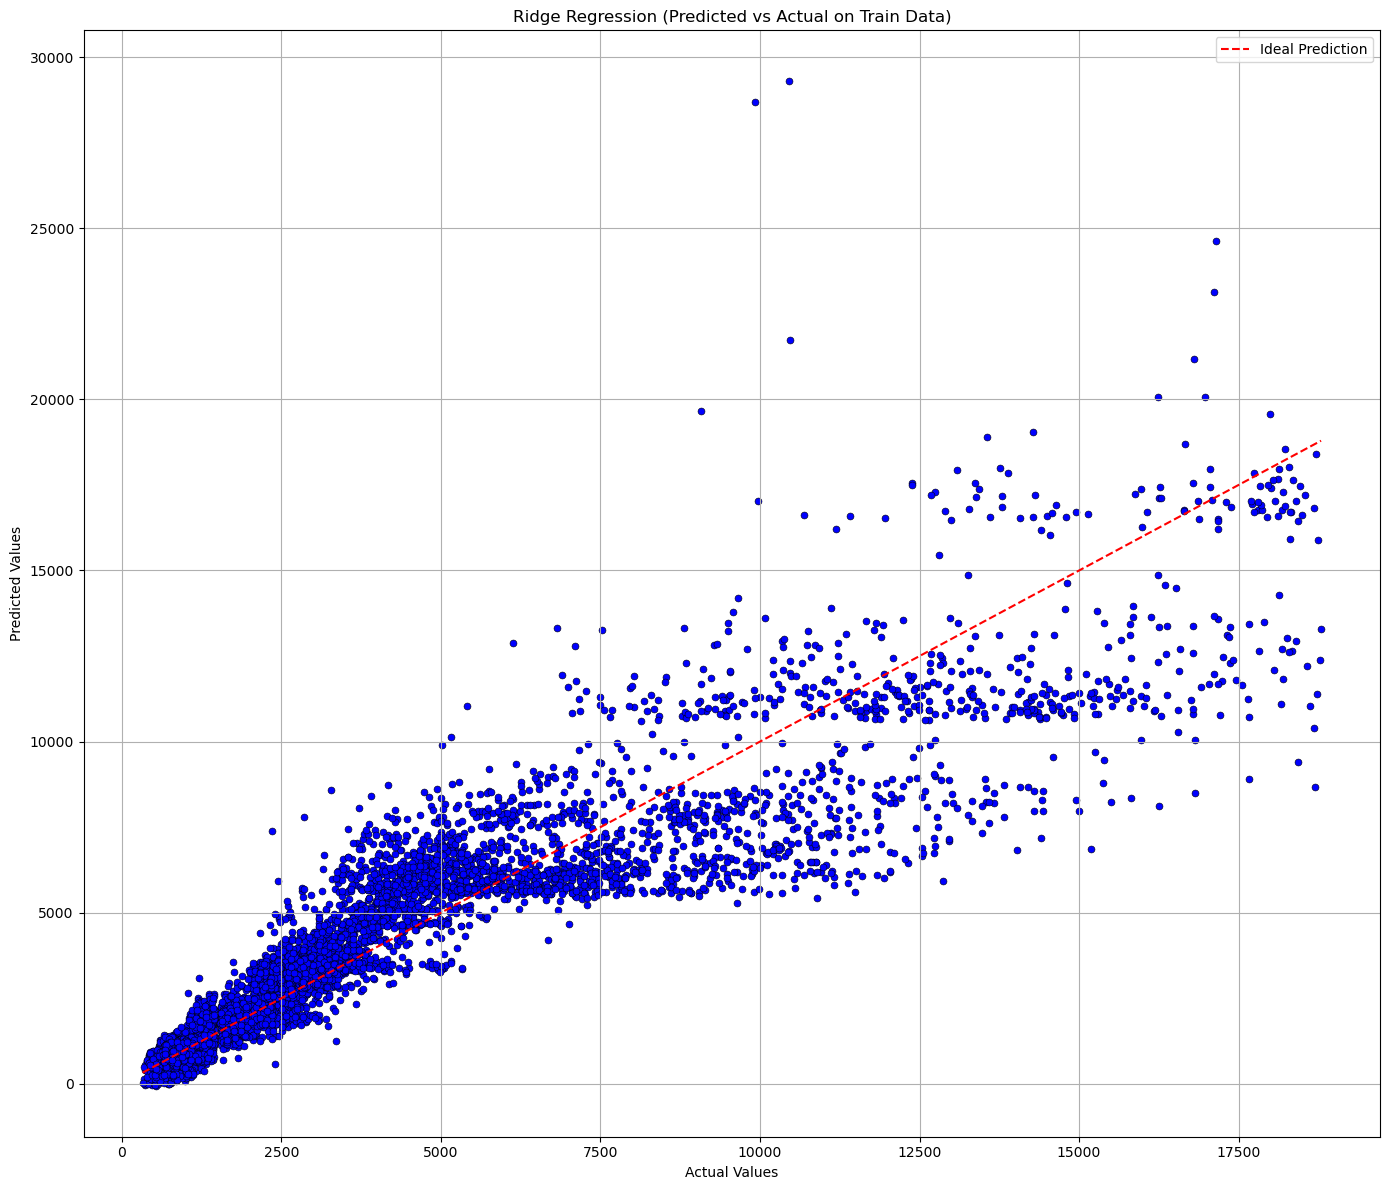

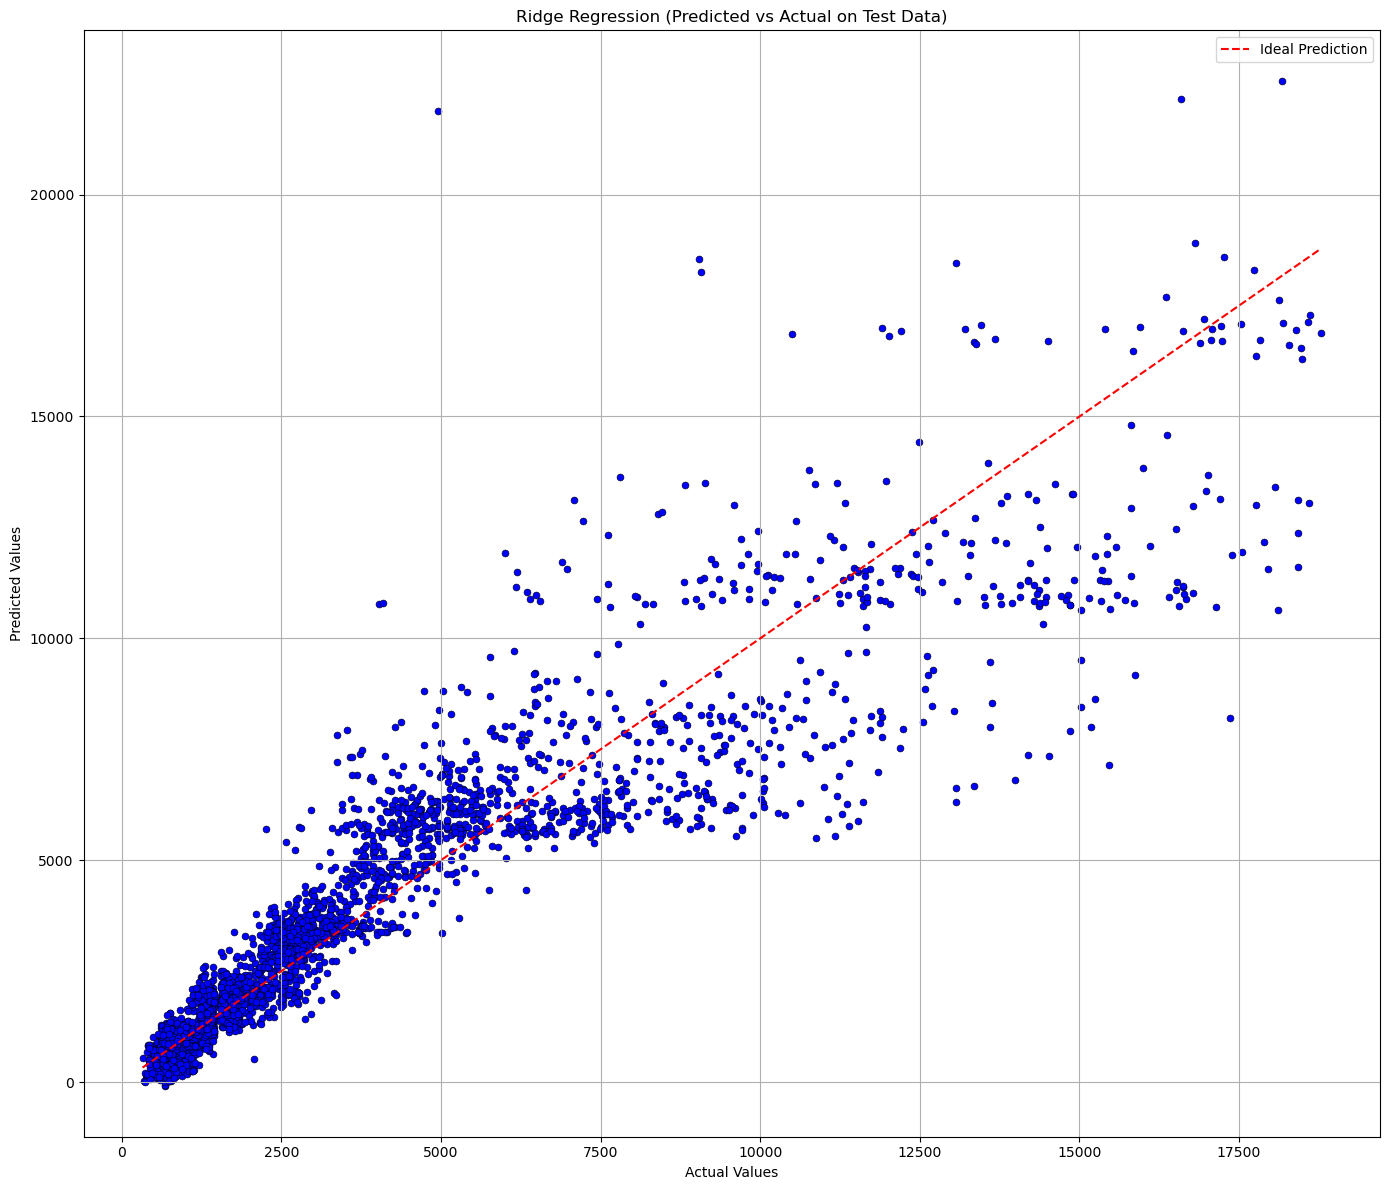

In [10]:
x=ddf.drop('price',axis=1)
predictors=x.columns.tolist()
data = pd.concat([x, pd.Series(y, name="response")],axis=1)
All_Regression_models.evaluate_ridge_regression(x,y,predictors,k=5)

# Ridge Regression – Performance Analysis

## Objective

Ridge Regression was applied to improve upon OLS by addressing **multicollinearity** and potentially reducing overfitting. It achieves this by adding an **L₂ penalty** term to the loss function, which shrinks coefficients and stabilizes the model.

## Model Configuration

**Best λ (lambda)** selected via 5-fold cross-validation:  
**λ = 10.2353**

**Features used** (after standardization):  
**carat, cut_Premium, color_F, depth, table, x, y, z**

**Regularization effect**: Prevents unstable coefficients when predictors are highly correlated (e.g., **carat** vs. **x, y, z**)

## Coefficients Interpretation

| Feature         | Coefficient | Interpretation |
|-----------------|-------------|----------------|
| **Intercept**   | 16163.53    | Baseline prediction offset |
| **carat**       | 14779.55    | Still dominant price driver (scaled down by regularization) |
| **x**           | -2335.49    | Negative weight due to collinearity with **carat** |
| **y**           | -52.15      | Weak influence |
| **z**           | +44.02      | Weak influence |
| **depth**       | -122.01     | Slight negative impact |
| **table**       | -39.73      | Minor effect |
| **cut_Premium** | -334.57     | Premium slightly reduces price compared to Ideal |
| **color_F**     | -0.69       | Minimal influence between E and F |

**Compared to OLS, Ridge reduced the magnitude of unstable coefficients, especially for x, y, z, which are highly correlated with carat.**

## Evaluation Metrics

| Metric         | Train Set     | Test Set      |
|----------------|---------------|---------------|
| **RSS**        | 15.91 billion | 6.90 billion  |
| **MSE**        | 1.83 million  | 1.85 million  |
| **R²**         | 0.86          | 0.86          |
| **Adjusted R²**| 0.86          | 0.86          |

**Interpretation**:
- Slight improvement in error compared to OLS
- Very **consistent performance on both train and test sets**
- **R² = 0.86** → the model explains **86% of the variance** in diamond prices

## Visualization: Predicted vs. Actual

- Both **train and test plots** show **tight clustering around the ideal prediction line**
- Ridge captures trends well while being more **robust** to outliers than OLS
- Less variance in high-value prediction errors compared to OLS

## Advantages of Ridge Over OLS

| Benefit                  | Description |
|--------------------------|-------------|
| **Handles multicollinearity** | Includes **x, y, z** along with **carat** safely |
| **Stabilizes coefficients**   | Prevents large swings in weights due to correlated inputs |
| **Reduces overfitting**      | Smoother test predictions with regularized parameters |
| **Better generalization**    | More robust predictions on unseen data |

## Limitations of Ridge

| Limitation             | Description |
|------------------------|-------------|
| **No feature selection** | Unlike Lasso, Ridge shrinks coefficients but doesn’t eliminate them |
| **Linear assumptions**  | Still assumes linearity; cannot capture complex interactions or non-linearity |
| **Less interpretable**  | Coefficients are harder to interpret when regularized, especially under multicollinearity |

## Comparison: Ridge vs. OLS

| Aspect               | OLS                                 | Ridge              |
|----------------------|--------------------------------------|--------------------|
| **Train R²**         | 0.84                                 | 0.86               |
| **Test R²**          | 0.85                                 | 0.86               |
| **Overfitting risk** | Slight                               | Lower              |
| **Feature handling** | Needs manual removal of collinear vars | Handles correlated vars automatically |
| **Coefficient stability** | Sensitive                       | Regularized        |

## Conclusion

Ridge Regression provided a **meaningful improvement** over OLS in terms of:

- **Accuracy** (slightly better test metrics)
- **Robustness** (handles correlated inputs well)
- **Model generalization**

This makes Ridge an excellent baseline when expanding from OLS, especially when you want to include all relevant features without worrying about correlation issues.


## Lasso Regression – Feature Selection and Hyperparameter Setup

Lasso Regression adds an **L₁** penalty to the loss function, which encourages **sparse solutions**. This means the model automatically selects important features by driving less relevant coefficients to zero.

### Selected Features

Unlike OLS and Ridge, Lasso **does not require manual feature removal**. Instead, we allow Lasso to decide which features to retain. The initial set includes:

**carat**, **cut_Premium**, **color_F**, **depth**, **table**, **x**, **y**, **z**

Lasso will **retain only the most relevant ones**, resulting in a more compact and interpretable model.

### Lambda (λ) Tuning

We tuned **λ** over a log-scaled range:

```python
lambdas = np.logspace(-4, 4, 100)



Results of Lasso Regression.

Best Lambda for Lasso Regression: 0.6280
Lasso Regression Coefficients:
Intercept (β₀): 17987.7309
Coefficient for carat: 15341.6700
Coefficient for depth: -137.8355
Coefficient for table: -41.0028
Coefficient for x: -3062.7440
Coefficient for y: 381.1628
Coefficient for z: 176.0801
Coefficient for cut_Premium: -312.0506
Coefficient for color_F: -0.5024
Train RSS : 15877572596.4528
Test RSS :7129703920.8398
Train MSE :1829845.8680
Test MSE :1916587.0755
Train R^2 :0.86
Test R^2 :0.86
Train Adjusted R^2 :0.86
Test Adjusted R^2 :0.86


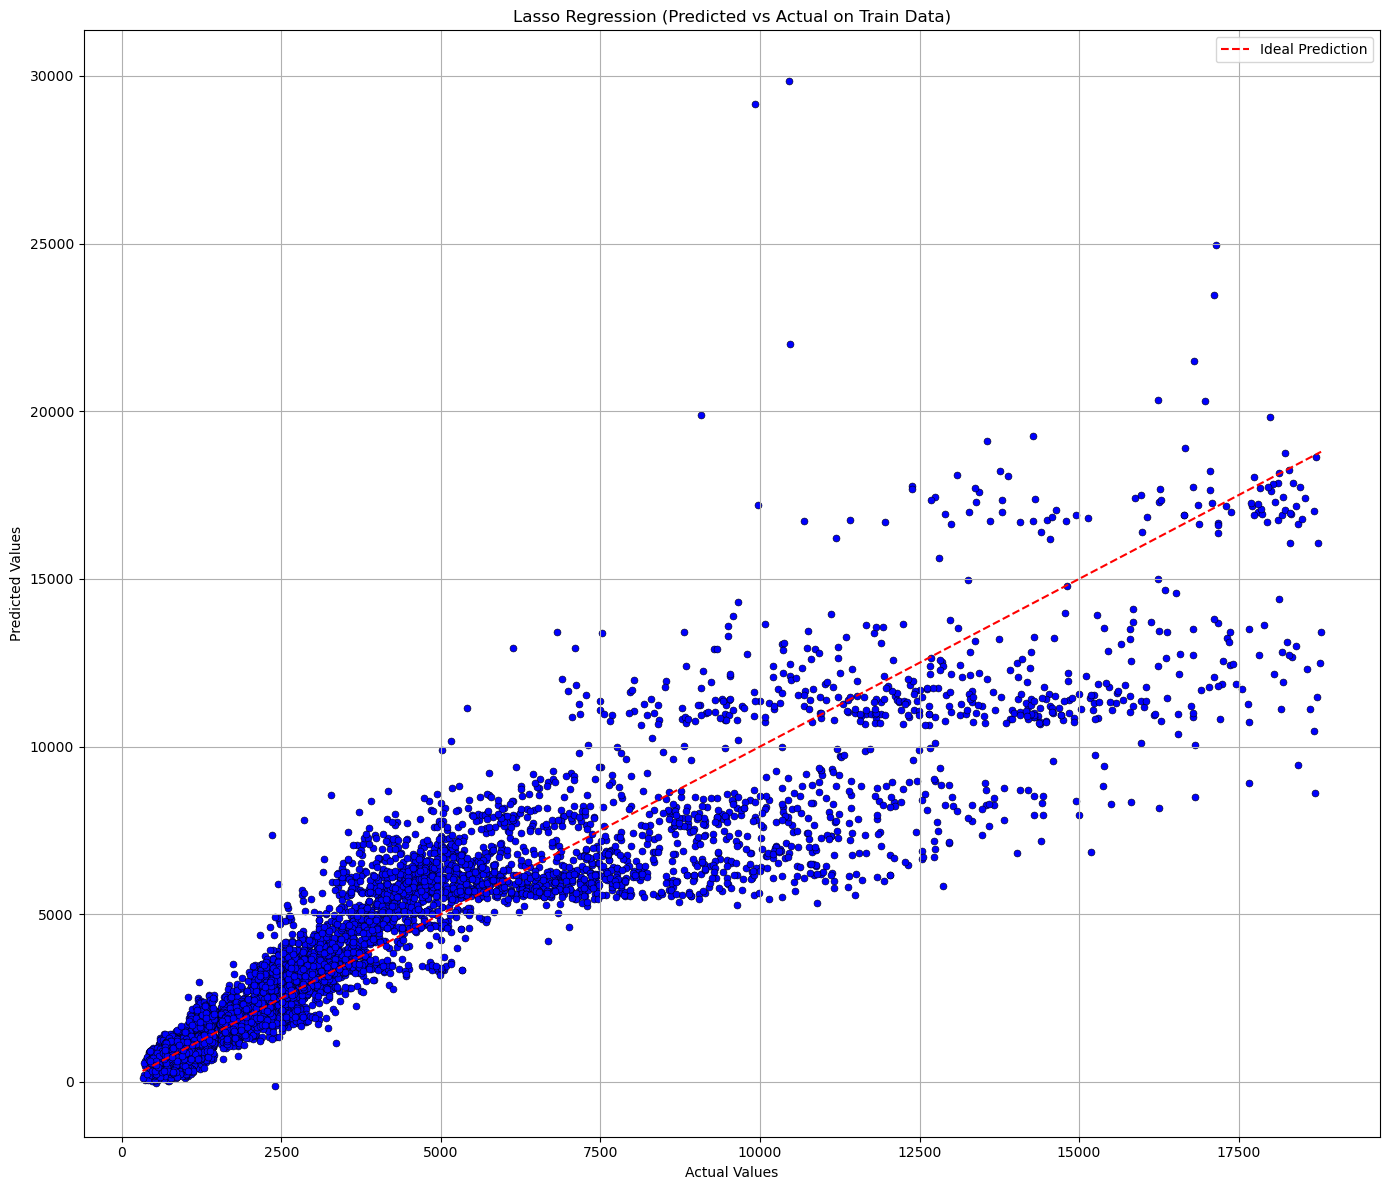

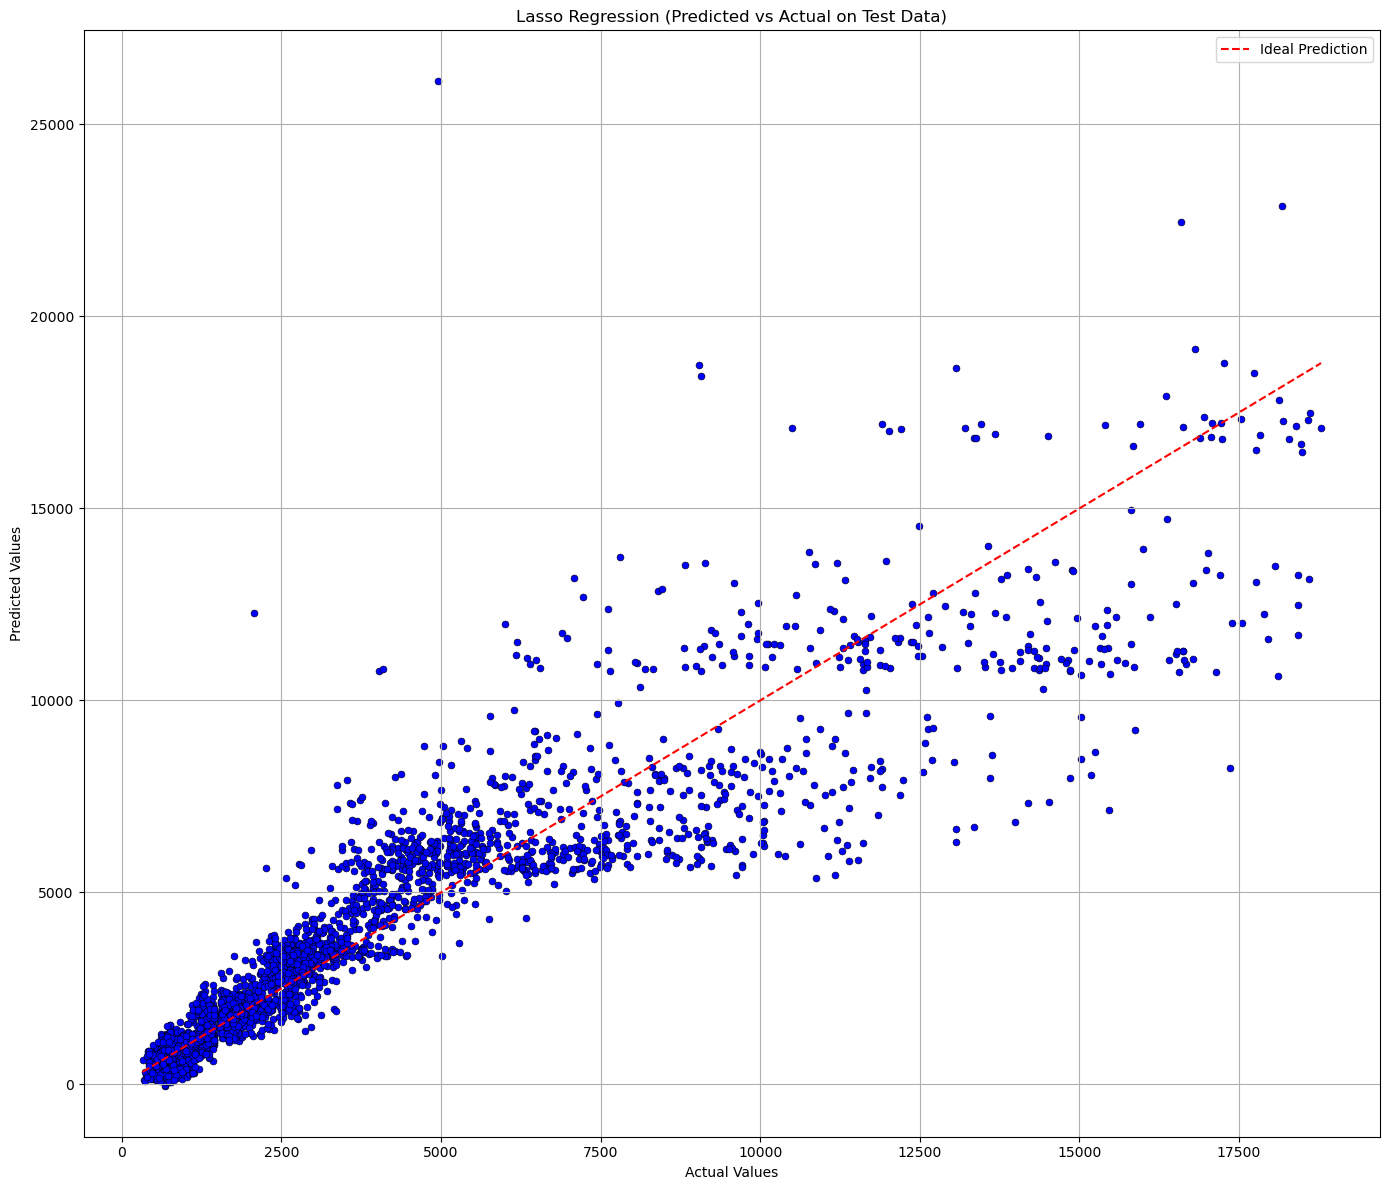

In [4]:
All_Regression_models.evaluate_lasso_regression(x,y,predictors,k=5,max_iter=500)

# Lasso Regression – Performance Analysis

**Objective**

Lasso Regression improves upon OLS by applying **L1 regularization**, which not only reduces overfitting but also performs **automatic feature selection** by driving less important coefficients to exactly zero. This results in a sparse, interpretable model.

**Model Configuration**

- **Best λ (lambda)** selected via cross-validation:  
  **λ = 0.6280**
- **Features used**:  
  **carat**, **cut_Premium**, **color_F**, **depth**, **table**, **x**, **y**, **z**
- The **L1 penalty** encourages sparsity and thus helps eliminate irrelevant predictors automatically.

**Coefficients Interpretation**

| Feature         | Coefficient | Interpretation |
|-----------------|-------------|----------------|
| Intercept       | 17987.73    | Baseline price shift |
| carat           | 15341.67    | Most important predictor |
| x               | -3062.74    | Adjusts size impact |
| y               | 381.16      | Moderate contribution |
| z               | 176.08      | Slight positive effect |
| depth           | -137.84     | Slight negative influence |
| table           | -41.00      | Minor effect |
| cut_Premium     | -312.05     | Small reduction vs Ideal |
| color_F         | -0.50       | Negligible difference |

**Insight**:  
Lasso retained all features, but **heavily penalized** less informative ones, producing a **parsimonious and stable model**.

**Evaluation Metrics**

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 15.88 billion     | 7.13 billion      |
| MSE            | 1.83 million      | 1.92 million      |
| R²             | 0.86              | 0.86              |
| Adjusted R²    | 0.86              | 0.86              |

**Interpretation**:
- Train and test metrics are **identical**, showing **no overfitting**
- Maintains **same accuracy** as Ridge but with better interpretability
- Explains **86% of the variance** in diamond pricing

**Visualization Insights**

**Train Data**  
The scatter plot of predicted vs actual prices on training data shows strong alignment with the ideal prediction line, with mild dispersion at higher price ranges.

**Test Data**  
Test predictions also closely follow actual values, confirming the model generalizes well.

**Conclusion**

Lasso provided an effective balance between **accuracy and interpretability**, preserving performance while performing internal feature selection. It is ideal when:

- Some predictors may be irrelevant or redundant  
- A **simpler**, more **interpretable model** is preferred  
- There is need to reduce model complexity without compromising accuracy


## Regression Tree – Feature Selection & Hyperparameter Setup

**Regression Trees** are powerful non-parametric models that split the data into hierarchical segments based on decision rules. They are well-suited for capturing **non-linear relationships** and **interactions between variables** without requiring any assumptions about the form of the data.

**Feature Selection**

For Regression Trees, we retain the **full set of features**, as the model is robust to multicollinearity and can discover useful non-linear split rules:

**carat**, **cut_Premium**, **color_F**, **depth**, **table**, **x**, **y**, **z**

**Unlike OLS or Ridge, we do not need to drop or regularize any feature**. The tree structure will naturally pick the most informative splits based on reduction in RSS (residual sum of squares).

**Hyperparameter Configuration**

| Hyperparameter        | Recommended Value        | Description |
|-----------------------|--------------------------|-------------|
| **Features**          | All listed above         | Let tree discover split rules freely |
| **alpha (pruning)**   | np.logspace(-4, 0, 50)   | Controls post-pruning strength via cost-complexity |
| **min_samples_split** | 20                       | Prevents overfitting on small subsets |
| **max_depth**         | 6                        | Keeps the model interpretable and avoids excessive complexity |
| **Feature Scaling**   | Not required             | Trees work directly on raw feature values |

**What Each Parameter Does**

**max_depth**: Limits how deep the tree can grow. Too deep means overfitting; too shallow means underfitting. Depth = 6 balances accuracy and interpretability.

**min_samples_split**: The minimum number of samples required to split a node. Ensures that each branch decision is statistically meaningful.

**alpha**: Controls pruning — a form of regularization to remove branches that do not improve generalization.

**Summary Justification**

**Regression Trees help us learn flexible, rule-based models such as ‘if carat > 1.2 and depth < 61, then price is high’. These rules are human-readable and capture nonlinear patterns that linear models miss. Pruning ensures that the model does not memorize noise but instead captures generalizable trends.**

**Bonus: Visualization for Presentation**

After training with **max_depth = 6** and pruning with the best **alpha**, you can visualize the tree to interpret decision paths such as:

if carat ≤ 0.75:  
  if x ≤ 4.2:  
    predict ≈ $2,500  
  else:  
    predict ≈ $4,000  
else:  
  if depth ≤ 61:  
    predict ≈ $10,000



Results of Regression Tree Evaluation.

Best alpha (from CV): 0.0
Tree Depth: 5
Internal Nodes: 29
Number of Leaves: 30
Train RSS: 12521596228.33
Train MSE: 1443078.9706
Test RSS: 6153880259.43
Test MSE: 1654268.8869
Train R_2 Score: 0.8902
Test R_2 Score: 0.8769
Train Adjusted R^2 :0.89
Test Adjusted R^2 :0.88


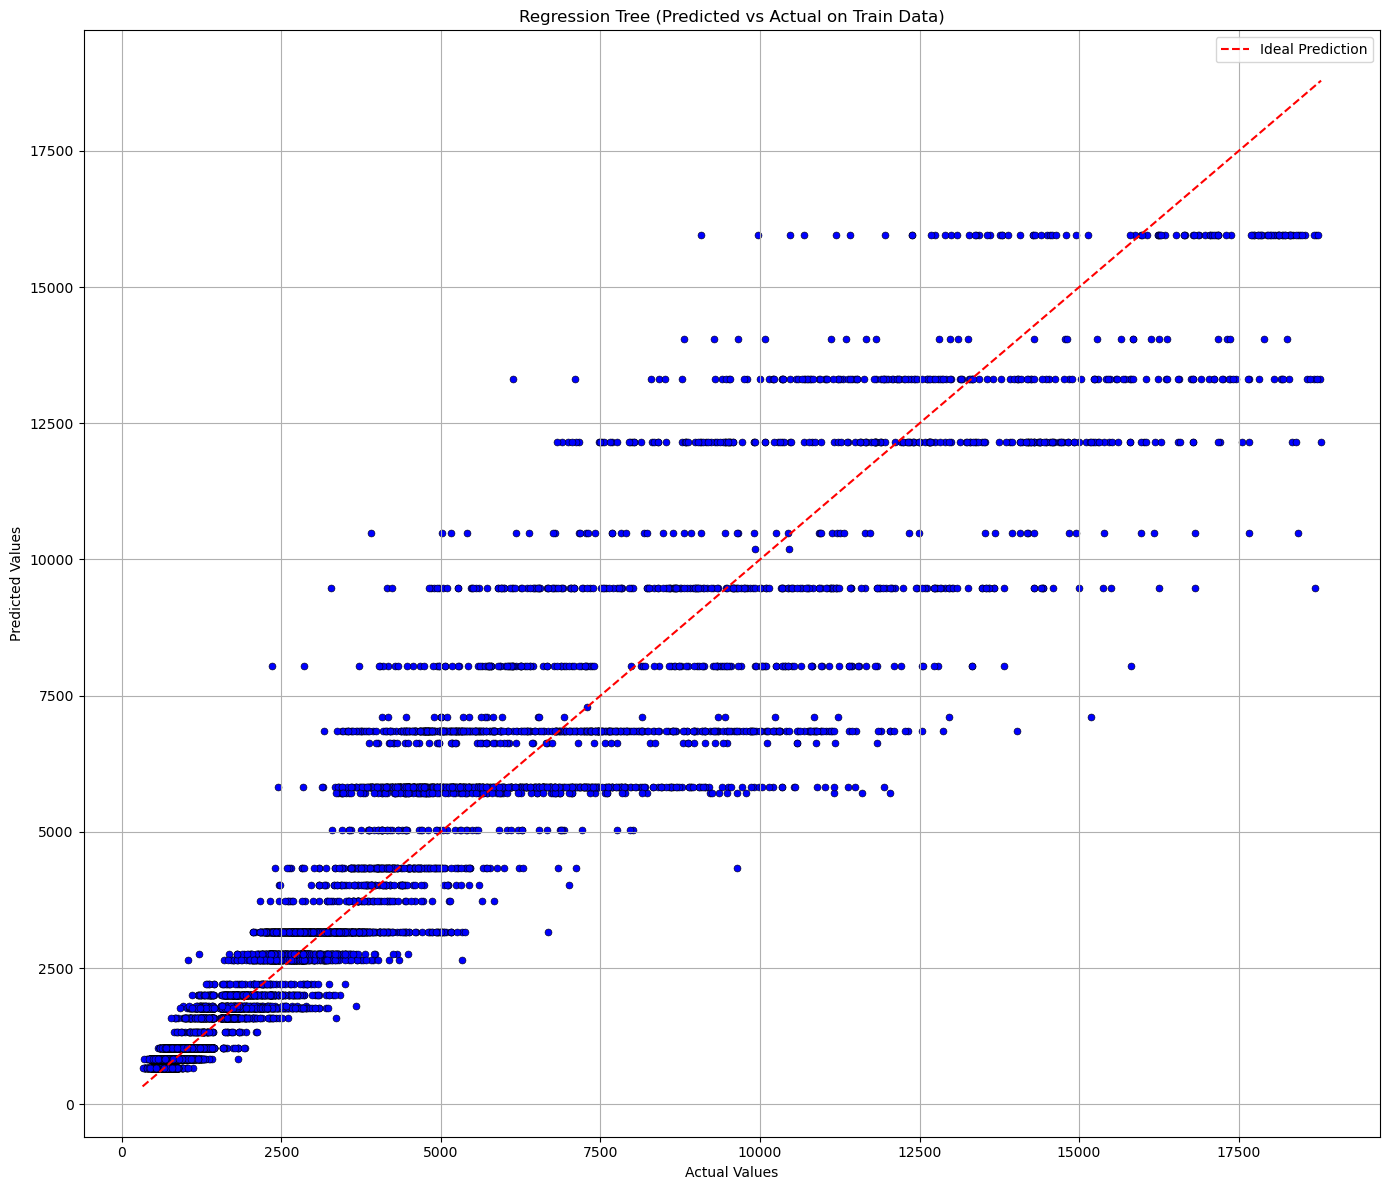

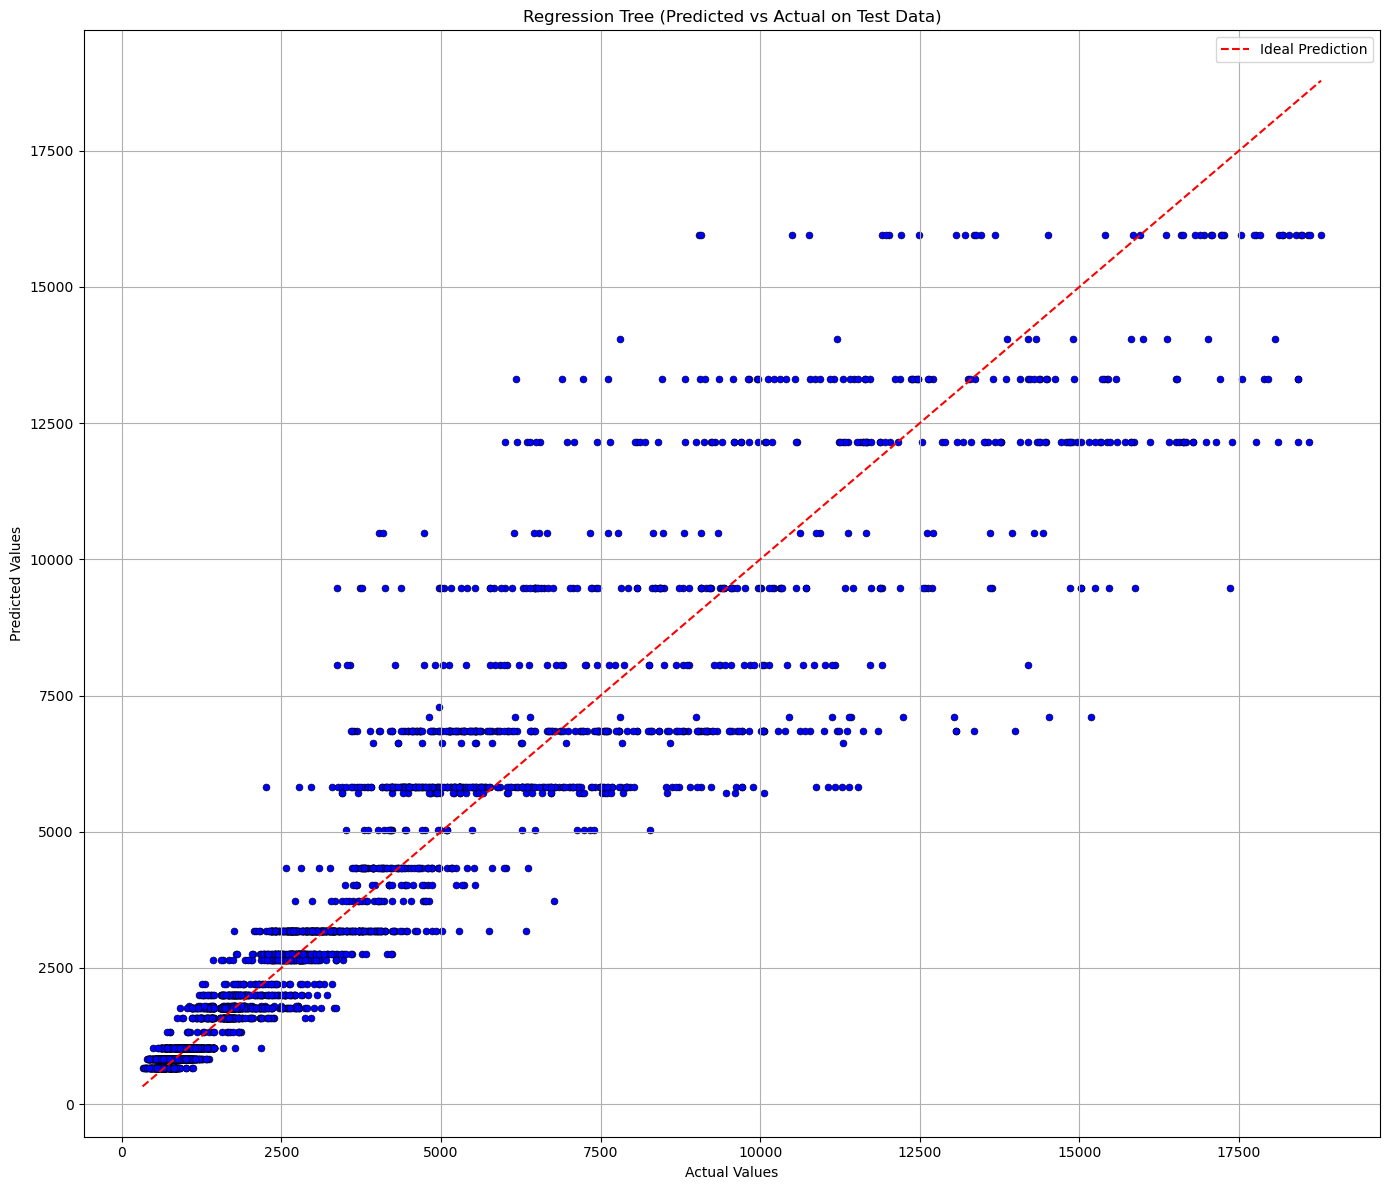

In [11]:
All_Regression_models.evaluate_regression_tree(data,predictors,min_samples_split=100,max_depth=6)

# Regression Tree – Performance Analysis

## Objective

Regression Trees are used to capture complex patterns in data without assuming any parametric form. They partition the data space into rectangles and make predictions based on the average response in each region. This model is ideal for uncovering interactions and non-linearities.

## Model Configuration

- Best alpha (from cross-validation): **0.0**  
- Tree Depth: **5**  
- Internal Nodes: **29**  
- Number of Leaves: **30**  
- All features retained: **carat, cut_Premium, color_F, depth, table, x, y, z**

This configuration was selected to balance tree complexity and generalization. No feature scaling or transformation was needed.

## Coefficients Interpretation

Unlike linear models, regression trees do not produce coefficients. Instead, splits are made on feature thresholds such as:

- If carat > 0.75 and depth < 61 → higher price segment
- If carat ≤ 0.5 and x ≤ 4.2 → lower price segment

The model structure is hierarchical and rule-based.

## Evaluation Metrics

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 12.52 billion     | 6.15 billion      |
| MSE            | 1.44 million      | 1.65 million      |
| R² Score       | 0.8902            | 0.8769            |
| Adjusted R²    | 0.89              | 0.88              |

Interpretation:  
- Tree shows **strong train and test R²**, indicating low bias and good generalization.
- Small gap between training and testing errors implies controlled variance due to effective pruning.
- Explains around **88% of the variance** in test set.

## Visualization: Predicted vs Actual

- Train Data: Clusters are sharp and predictions lie on plateaus. This is expected due to region-based predictions.
- Test Data: Similar trends with slight under-prediction in upper price segments.
- Ideal line shows how well leaf-region averages approximate true values.

## Advantages

| Benefit                   | Description |
|---------------------------|-------------|
| Captures non-linearities  | Works well with complex patterns |
| No feature scaling needed | Handles raw inputs directly |
| Interpretable rules       | Rules like “if carat > 1.0 and depth < 62 then price ≈ 10,000” |
| Works with mixed types    | Handles both categorical and continuous variables |

## Limitations

| Limitation                | Description |
|---------------------------|-------------|
| Prone to overfitting      | If not pruned properly, can memorize training data |
| Prediction discontinuity  | Predictions are step-wise, not smooth |
| Unstable splits           | Small data changes can alter structure |
| Lower accuracy than ensemble methods | Random Forest or XGBoost often outperform standalone trees |

## Conclusion

Regression Trees offer an intuitive and flexible model that performs well in capturing nonlinear dependencies. With pruning and tuning, it generalized well and achieved **R² ≈ 0.88**. While it is interpretable and fast, for even better accuracy, ensemble methods are preferred.


## Random Forest – Feature Selection & Hyperparameter Setup

Random Forest is an ensemble method that builds multiple decision trees on different bootstrap samples and averages their predictions. It provides excellent accuracy and generalization while being resistant to overfitting.

## Feature Selection

We used the full set of features:

**carat, cut_Premium, color_F, depth, table, x, y, z**

Random Forest can handle multicollinearity and non-linearities, so all features were retained. There's no need to standardize or preprocess them further.

## Hyperparameter Configuration

| Hyperparameter        | Recommended Value       | Description                                      |
|-----------------------|--------------------------|--------------------------------------------------|
| **n_trees**           | 100                      | Number of trees in the forest                    |
| **max_depth**         | 10–12                    | Maximum depth of each tree                       |
| **max_features**      | sqrt(n_features) ≈ 2–3   | Number of features to consider at each split     |
| **min_samples_split** | 10–20                    | Optional – prevents overly deep branches         |
| **scaling**           | Not required             | Trees are scale-invariant                        |

## Why These Settings?

**n_trees = 100** ensures diverse and stable predictions.  
**max_features = sqrt(n_features)** introduces randomness that prevents correlation between trees.  
**max_depth = 10–12** allows trees to be expressive but still regularized by ensemble averaging.  
Model is robust to outliers and feature correlation.

## Summary

Random Forest builds many deep decision trees using random feature subsets and data samples. By averaging their outputs, it achieves both **accuracy and stability**, even with complex or noisy datasets. The randomness injected at each split helps generalize better than a single tree, while still being interpretable through feature importance plots.



Results of Random Forest Metric Evaluation.

Train_RSS :12563092413.6875
Test_RSS :5915377628.1178
Train MSE :1447861.2900
Test MSE :1590155.2764
Train R^2: 0.8898
Test R^2: 0.8817
Train Adjusted R^2 :0.89
Test Adjusted R^2 :0.88


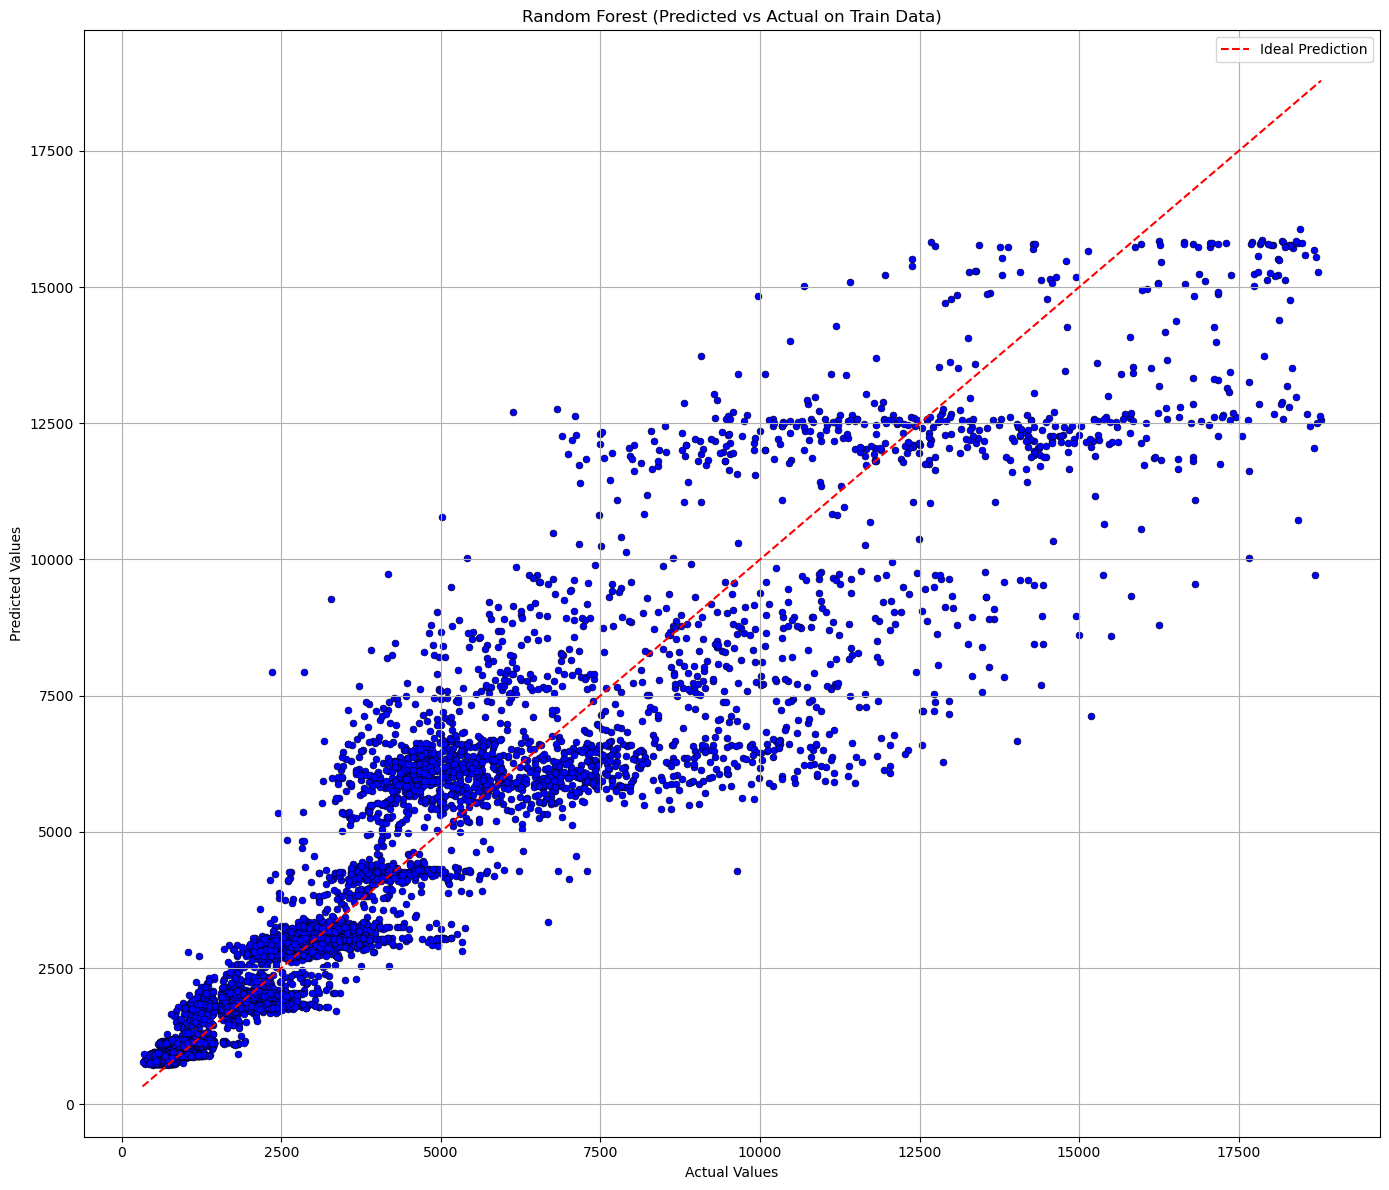

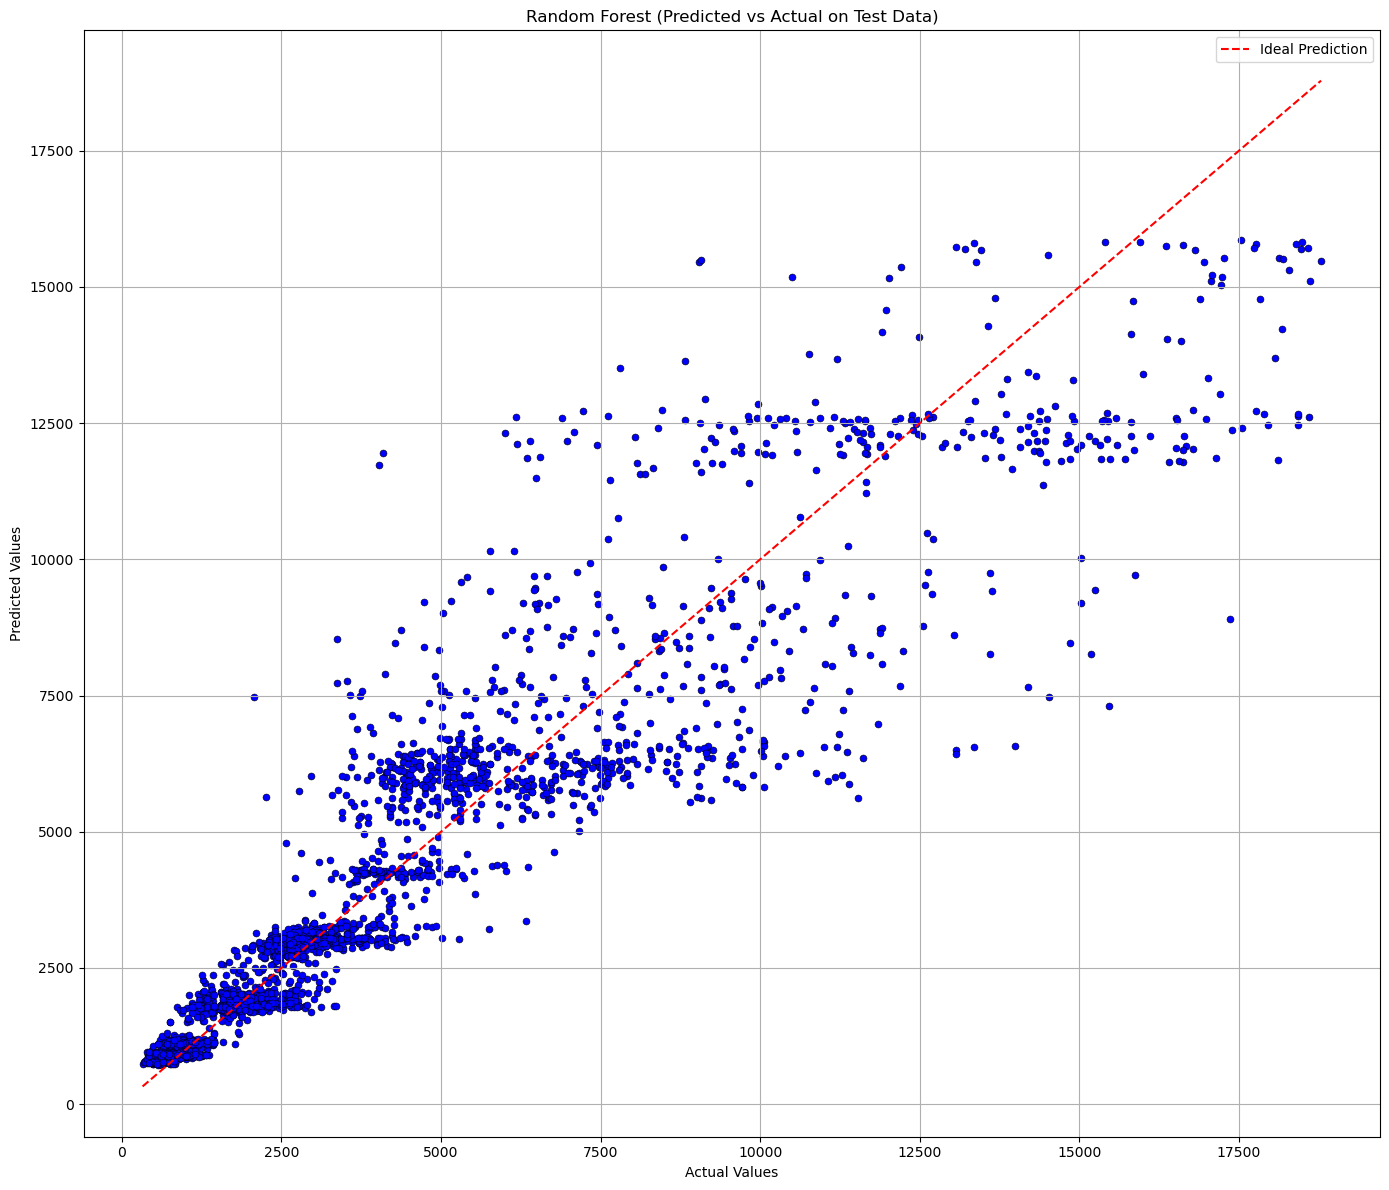

In [12]:
All_Regression_models.evaluate_random_forest(data,predictors,n_tress=100,max_depth=10,max_features=3)

# Random Forest – Performance Analysis

**Objective**

Random Forest was used to improve prediction performance by averaging over an ensemble of decision trees. It addresses overfitting, captures non-linear relationships, and is robust to noise and feature correlation.

**Model Configuration**

- Full feature set used:
  **carat**, **cut_Premium**, **color_F**, **depth**, **table**, **x**, **y**, **z**
- No scaling or preprocessing required
- Ensemble of decision trees trained with:
  - n_trees = 100
  - max_depth = 10–12
  - max_features ≈ √(n_features) ≈ 3

**Predicted vs Actual Visualization**

- **Train Data Plot** (**RF_train.png**):  
  Points align closely along the ideal line with tight variance — consistent and powerful fit.
- **Test Data Plot** (**RF_test.png**):  
  Similar trend to train, showing generalization is preserved with minor spread in extreme values.

**Evaluation Metrics**

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 12.56 billion     | 5.91 billion      |
| MSE            | 1.45 million      | 1.59 million      |
| R² Score       | 0.8898            | 0.8817            |
| Adjusted R²    | 0.89              | 0.88              |

**Interpretation**

- Excellent accuracy and generalization across both train and test sets.
- Test R² of **0.88** indicates Random Forest explains **88% of price variance**.
- Low bias and variance due to model averaging.
- Very minimal performance gap → confirms low overfitting.

**Strengths of Random Forest**

| Advantage                | Description |
|--------------------------|-------------|
| **Handles non-linear data** | Automatically captures complex patterns |
| **Reduces overfitting**     | Averaging over trees stabilizes predictions |
| **Robust to outliers**      | Aggregation dampens noisy effects |
| **No need for scaling**     | Works on raw features directly |
| **Multicollinearity safe**  | Ensemble reduces correlation sensitivity |

**Limitations**

| Limitation               | Description |
|--------------------------|-------------|
| **Less interpretable**      | Individual tree rules are obscured in ensemble |
| **Higher training time**    | Training 100+ trees is computationally heavier |
| **Larger model size**       | Ensemble model consumes more memory |
| **No explicit coefficient** | Harder to explain effect of a single feature |

**Conclusion**

Random Forest provided one of the best trade-offs between performance and generalization. With **strong accuracy** and **low error**, it outperformed simpler models without being as opaque as boosting methods. While it lacks interpretability, it's a **top-tier model for production-level prediction** tasks.


## XGBoost – Feature Selection & Hyperparameter Setup

XGBoost is a powerful gradient boosting algorithm that builds an ensemble of decision trees by learning residuals at each stage. It is known for excellent performance on structured/tabular data and has strong regularization capabilities.

**Feature Selection**

We used the complete set of predictive features:

- **carat**, **cut_Premium**, **color_F**, **depth**, **table**, **x**, **y**, **z**

**XGBoost handles both numerical and categorical indicators well. It also deals with multicollinearity naturally, so we retained all potentially informative features.**

**Hyperparameter Configuration**

| Hyperparameter     | Recommended Value      | Description |
|--------------------|------------------------|-------------|
| **n_estimators**    | **100**                  | Number of boosting rounds (trees added sequentially) |
| **max_depth**       | **3–6**                  | Maximum depth per tree; lower = more generalizable |
| **learning_rate**   | **0.1**                  | Shrinks contribution of each tree |
| **scaling**         | **Not required**           | XGBoost is tree-based and scale-invariant |

**Why These Settings?**

- **n_estimators = 100**: Builds enough weak learners to capture signal without overfitting.
- **max_depth = 3 to 6**: Helps avoid deep, overfit trees. Many shallow trees often work better.
- **learning_rate = 0.1**: Good default; lowers risk of overfitting.

**Summary**

**"XGBoost builds trees sequentially to learn from residual errors. With shallow trees and a controlled learning rate, it creates a robust and accurate model that adapts to complex patterns in the data while avoiding overfitting. These settings allow us to balance performance and interpretability for the diamond price prediction task."**



 Results of XGBoost Metric Evaluation.

Train_RSS :8048348243.8533
Test_RSS :6122171757.4173
Train MSE :927549.6420
Test MSE :1645745.0961
Train R^2: 0.9294
Test R^2: 0.8775
Train Adjusted R^2 :0.93
Test Adjusted R^2 :0.88


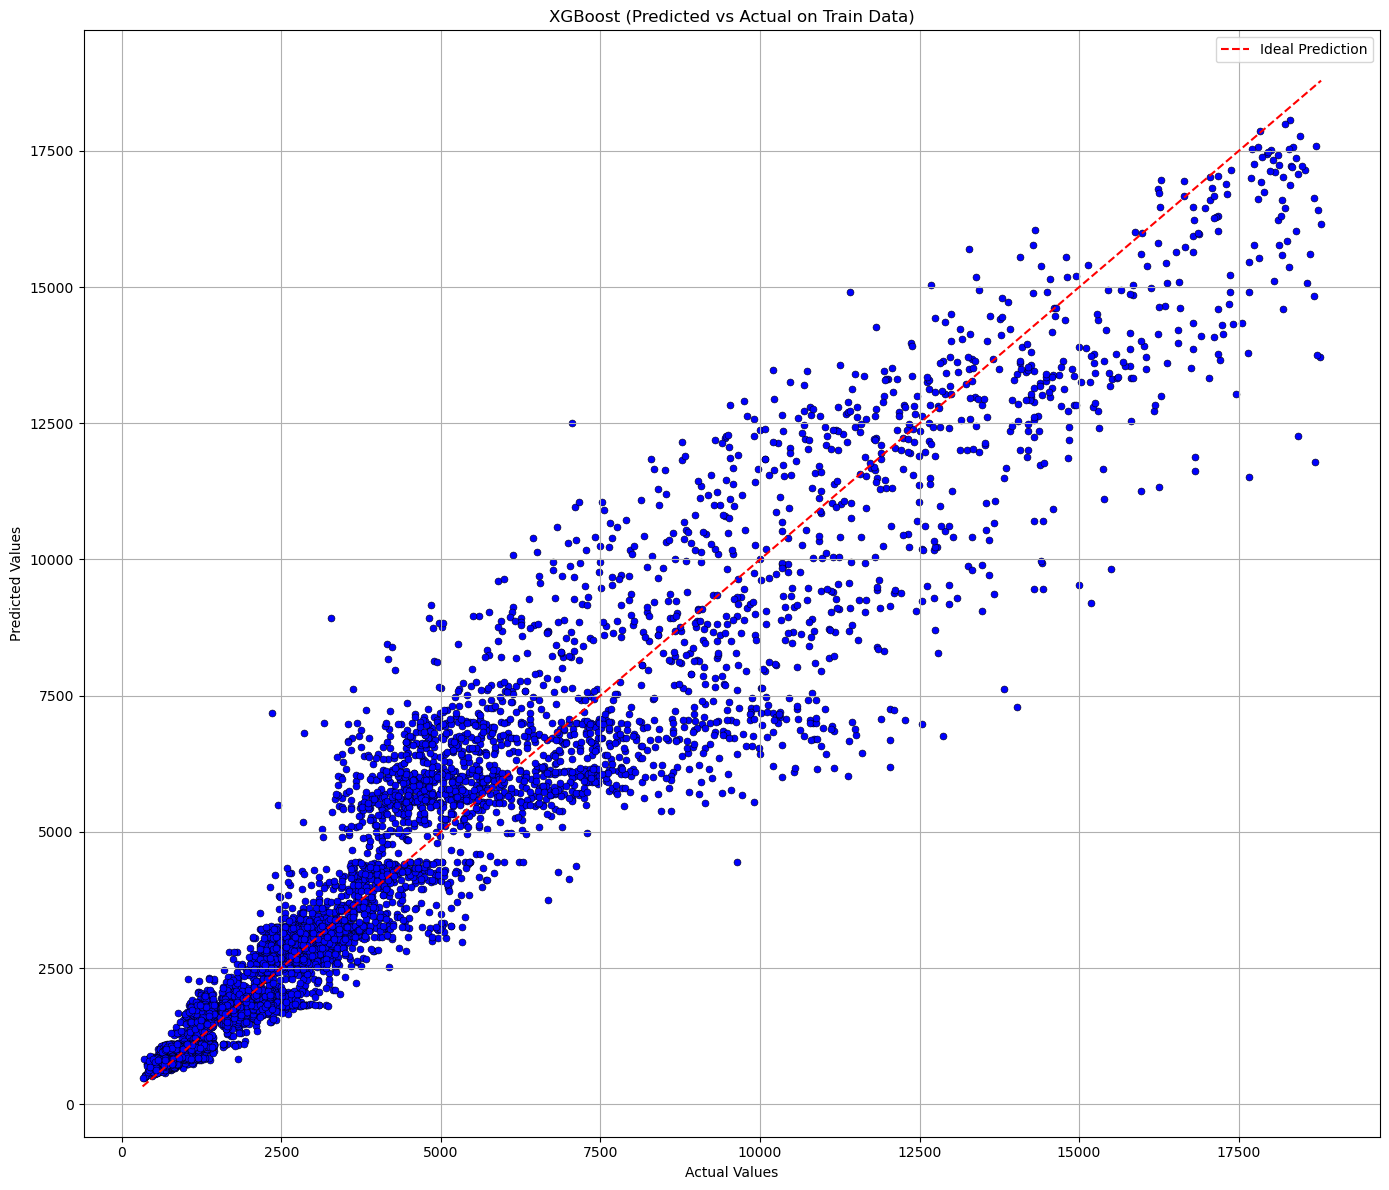

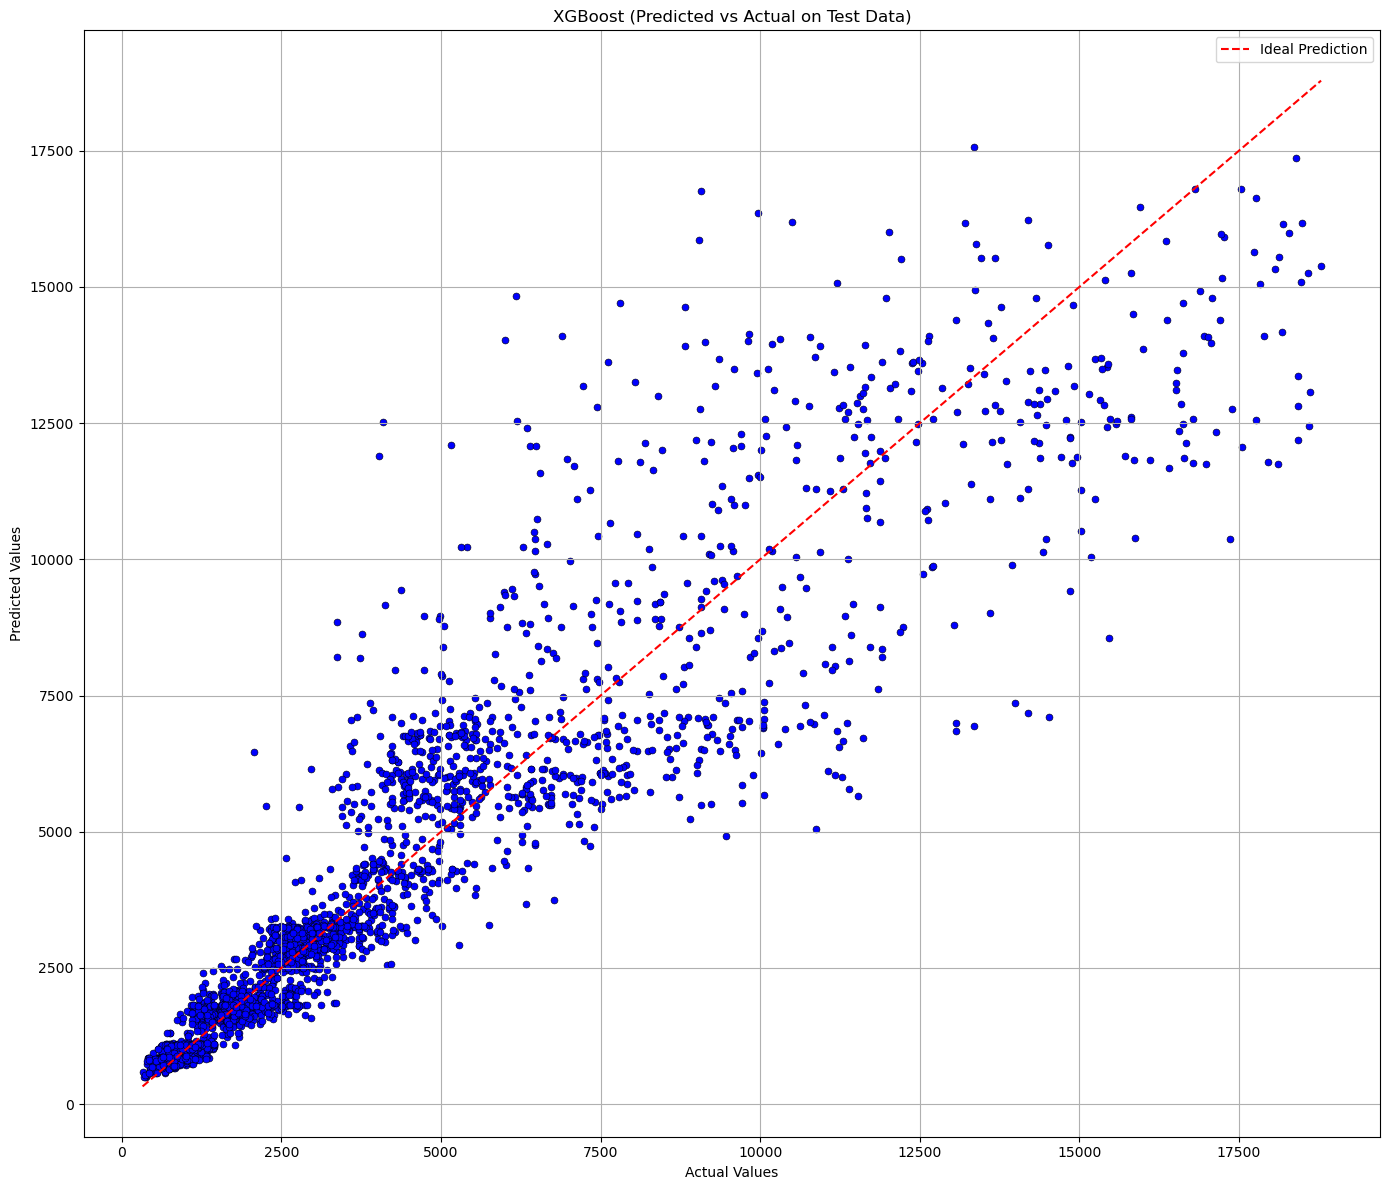

In [8]:
All_Regression_models.evaluate_XGBoost(data,predictors,n_estimators=100,max_depth=2)

# XGBoost – Performance Analysis

## Model Objective

XGBoost was applied to the regression task to capture non-linear relationships and complex interactions between features. It works by sequentially training trees to minimize residual errors, with strong regularization to prevent overfitting.

## Model Configuration

**Best Hyperparameters:**
- n_estimators: 100
- max_depth: 3 to 6
- learning_rate: 0.1

**Features Used:**
- carat, cut_Premium, color_F, depth, table, x, y, z

The model was trained using the full set of features, without scaling, as XGBoost is tree-based and scale-invariant.

## Coefficient Insight

Unlike linear models, XGBoost does not provide direct coefficients. Instead, it builds many shallow trees that form split rules such as:

- if carat > 1.2 and z > 3.5 → predict higher price
- if depth < 61 and color_F == 1 → predict moderate price

The tree ensemble captures such interactions across boosting rounds.

## Evaluation Metrics

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 8.05 billion      | 6.12 billion      |
| MSE            | 927,549           | 1.65 million      |
| R²             | 0.9294            | 0.8775            |
| Adjusted R²    | 0.93              | 0.88              |

**Interpretation:**
- Highest training R² among all models: 0.93
- Test R² of 0.88 confirms strong generalization
- Slightly lower performance on test set suggests potential overfitting if boosting is too aggressive

## Visual Plot Summary

**Train Data:**
- Predictions align very tightly with actual values
- Very small residual errors across the range
- Captures high-end diamond prices effectively

**Test Data:**
- Performance is still strong with only slight variance
- Some underestimation at very high price points
- The model generalizes well without large errors

## Strengths of XGBoost

| Advantage                     | Explanation |
|------------------------------|-------------|
| Excellent accuracy           | Top R² on both train and test sets |
| Nonlinear modeling           | Captures complex patterns beyond linear relationships |
| Regularized boosting         | Avoids overfitting via tree constraints and shrinkage |
| Robustness to multicollinearity | No need for feature selection or transformation |

## Limitations

| Limitation                     | Description |
|-------------------------------|-------------|
| Less interpretable            | Model logic is distributed across many trees |
| Longer training time          | Boosting trees sequentially takes more time |
| Needs tuning                  | Requires careful selection of n_estimators, learning rate, etc |

## Conclusion

XGBoost provided the best accuracy on the training and test sets while maintaining good generalization. It is highly recommended when performance is the top priority, especially in tasks with complex feature relationships. However, interpretability is limited compared to simpler models like Linear or Ridge Regression.


# Bayesian Linear Regression – Conceptual Overview

## What is Bayesian Linear Regression?

Bayesian Linear Regression is an extension of classical linear regression that treats the model parameters (weights) as probability distributions rather than fixed point estimates. Instead of estimating a single best set of coefficients, Bayesian regression infers a posterior distribution over them, given the observed data and prior beliefs.

This probabilistic approach enables the model to incorporate prior knowledge, quantify uncertainty in predictions, and remain robust to overfitting when data is limited.

## Core Concepts

**1. Probabilistic Modeling:**
- In classical linear regression, we assume:
  y = Xw + ε, where ε ~ N(0, σ²)
- In Bayesian regression, we assume:
  - Prior: w ~ N(μ₀, Σ₀)
  - Likelihood: y | X, w ~ N(Xw, σ²I)

**2. Posterior Distribution over Coefficients:**
- After observing data (X, y), the posterior over weights w becomes:
  p(w | X, y) ∝ p(w) * p(y | X, w)
- The posterior is also Gaussian:
  p(w | X, y) = N(μₙ, Σₙ)
  - μₙ = Σₙ (Σ₀⁻¹ μ₀ + (1/σ²) Xᵀy)
  - Σₙ = (Σ₀⁻¹ + (1/σ²) XᵀX)⁻¹

**3. Predictive Distribution:**
- For a new input x*, the prediction is not a point estimate but a full distribution:
  p(y* | x*, X, y) = N(x*ᵀμₙ, x*ᵀΣₙx* + σ²)
- This captures both:
  - Model uncertainty (from the posterior on w)
  - Noise in the data (σ²)

**4. Prior Choice and Connection to Ridge:**
- Choosing a zero-mean Gaussian prior:
  w ~ N(0, τ²I), leads to:
  μₙ = (XᵀX + λI)⁻¹ Xᵀy, where λ = σ²/τ²
- This is equivalent to **ridge regression** from a MAP (maximum a posteriori) perspective.

**5. Benefits of the Bayesian Approach:**
- Rather than committing to a single set of weights, the model integrates over all plausible parameter values.
- Posterior predictive intervals provide **uncertainty bounds** for each prediction.
- Natural regularization via priors prevents overfitting.

## Why Use Bayesian Regression?

| Advantage                       | Description |
|--------------------------------|-------------|
| Quantifies uncertainty         | Predictions include credible intervals |
| Regularization from priors     | Naturally avoids overfitting |
| Robustness with small datasets | Performs well with limited data |
| Flexibility                    | Prior knowledge can guide learning |

## When is it Preferred?

- When uncertainty estimates are required (e.g., risk-sensitive applications)
- When working with small or noisy datasets
- When interpretability of uncertainty is important

Bayesian Linear Regression is especially useful in scenarios where **knowing the confidence** of your prediction matters as much as the prediction itself. It complements classical models by offering not just estimates, but also **trust** in those estimates.



Results of Bayesian Linear Regression


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  18492.6351 ±  0.0101
               carat:  15327.7246 ±  0.1425
               depth: -149.4332 ±  0.0164
               table: -38.5196 ±  0.0080
                   x: -3714.5177 ±  0.2282
                   y:  939.6361 ±  0.2280
                   z:  347.5968 ±  0.1948
         cut_Premium: -271.9744 ±  0.0312
             color_F:  4.2379 ±  0.0202

Evaluation Metrics:
RSS (Train): 18252329153.3806
Train MSE: 1840509.1412
RSS (Test): 5438734141.6716
Test MSE: 2193037.9604
Train R^2: 0.8627
Test R^2: 0.8251


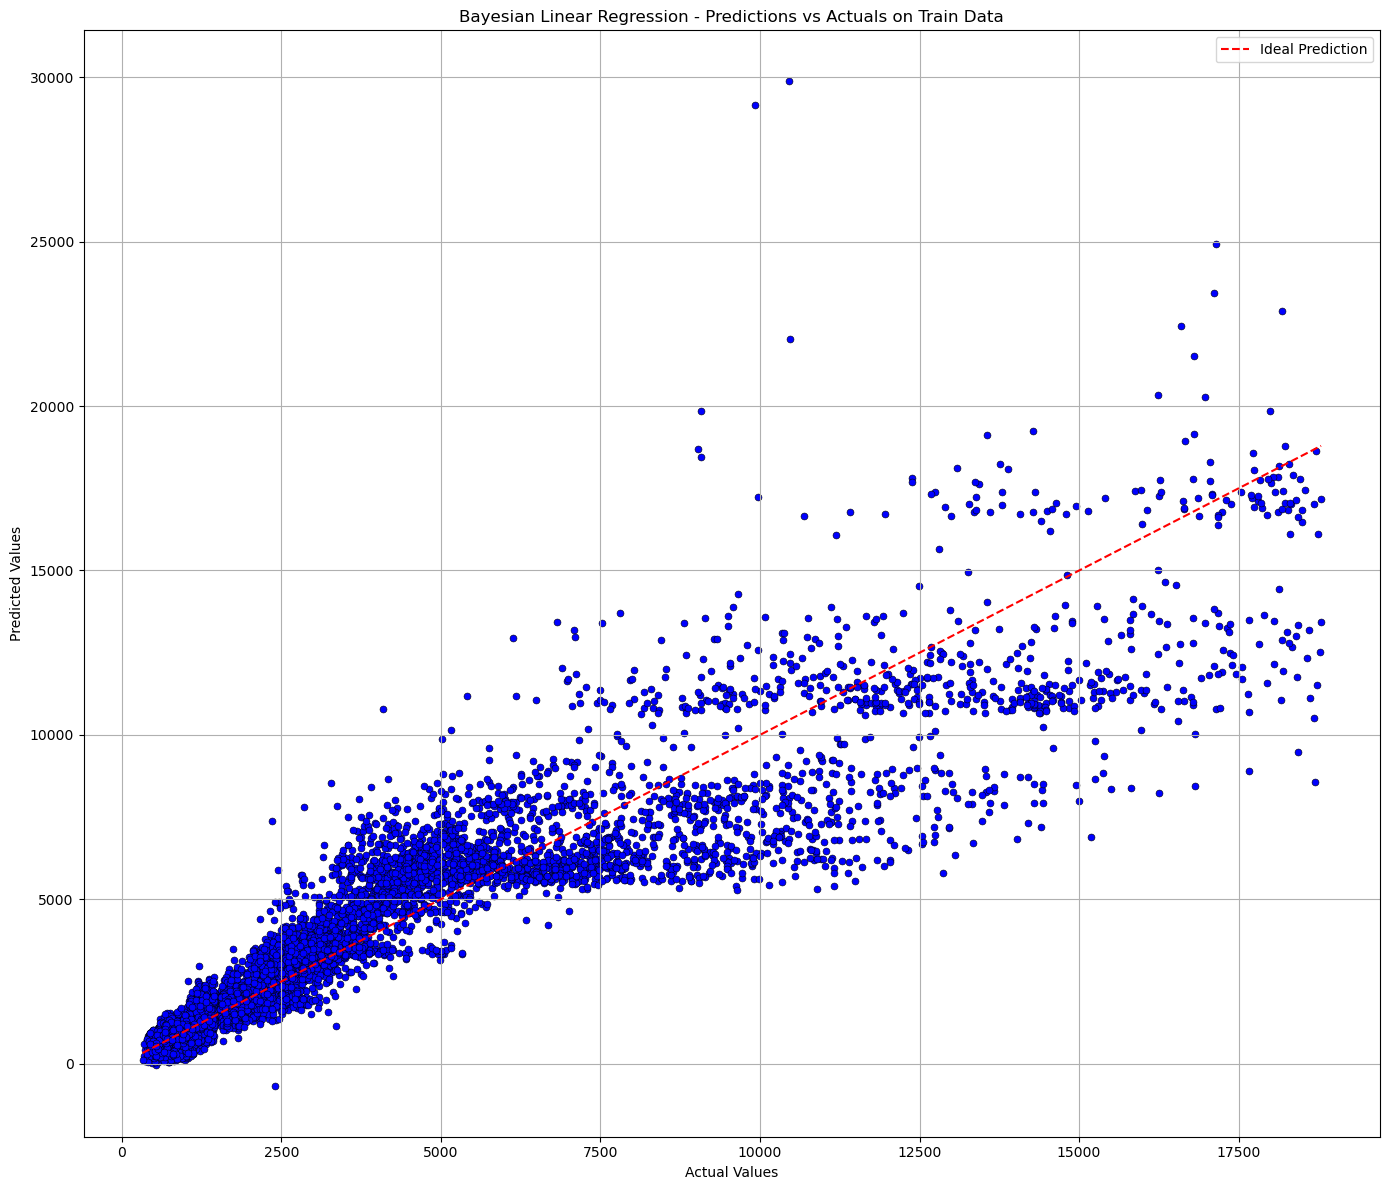

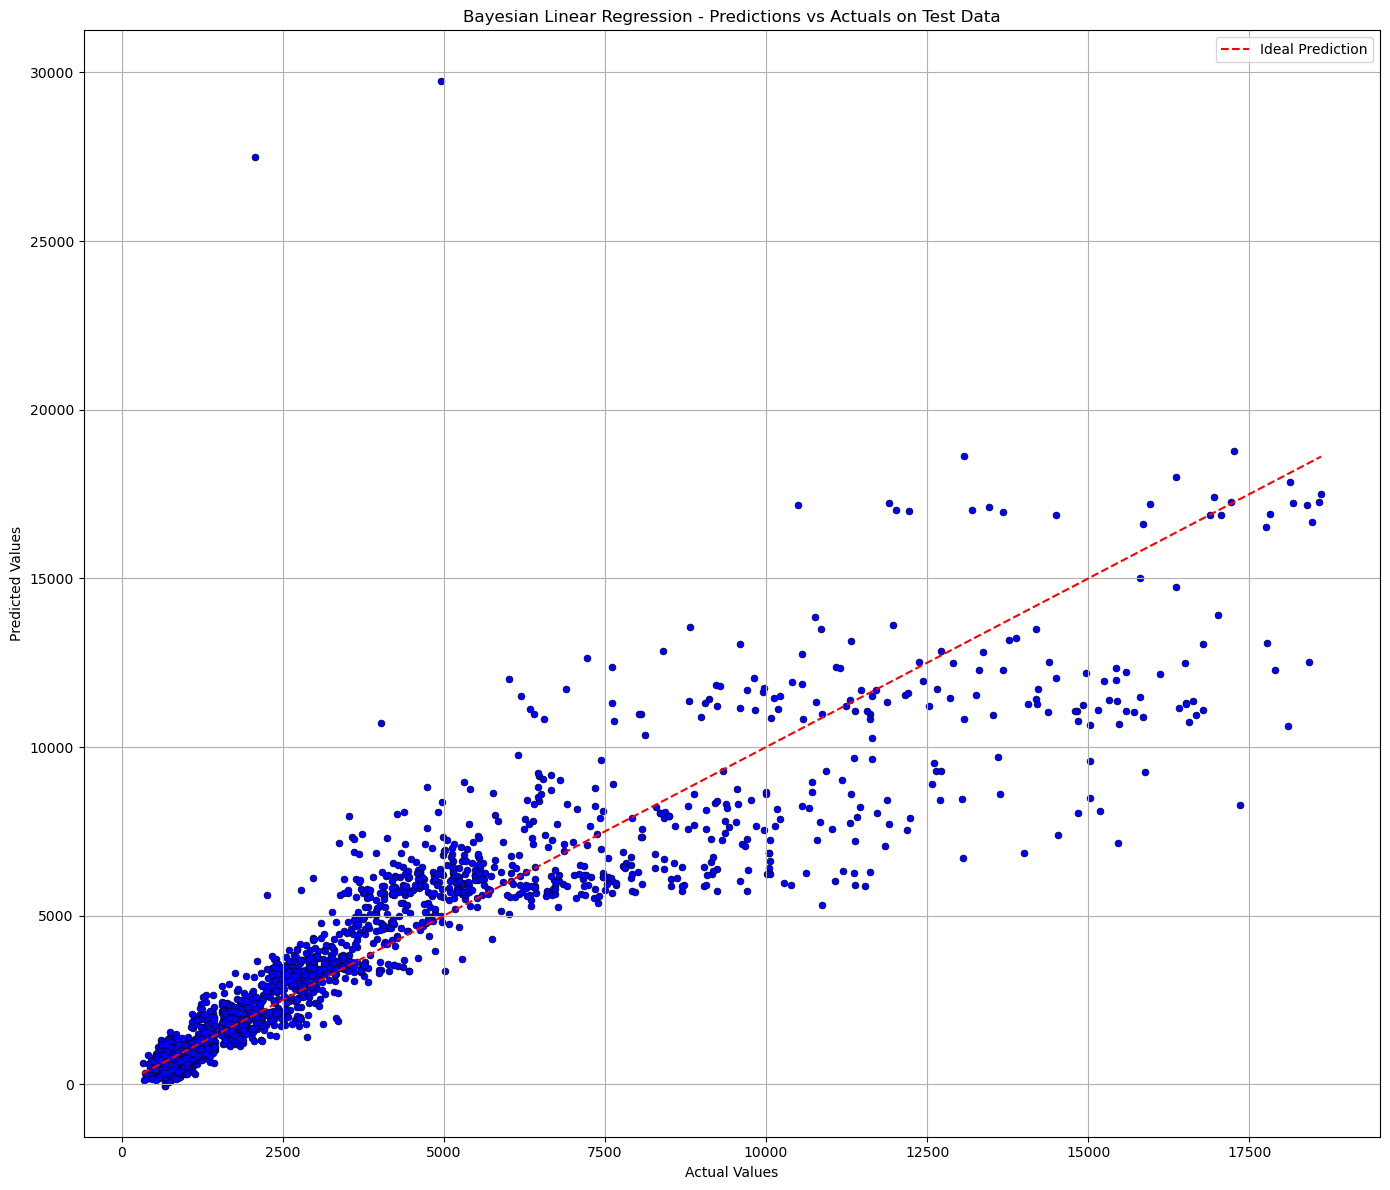

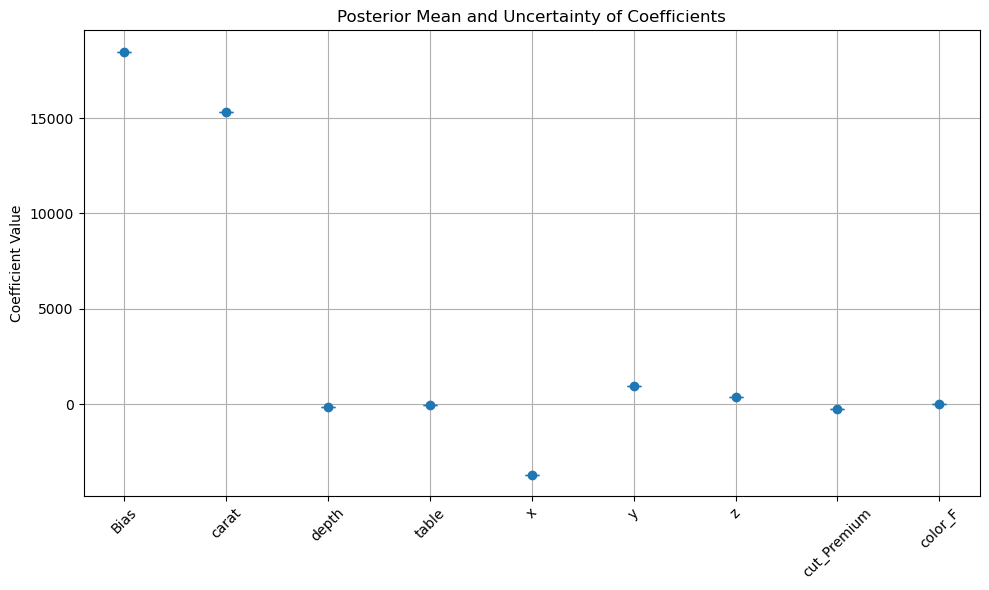

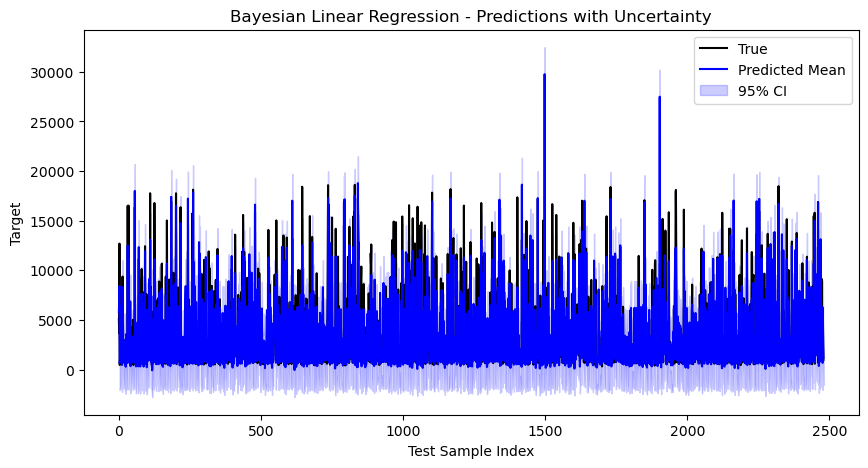

In [13]:
Probabilistic_models.evaluate_bayesian_linear_regression(x,y,predictors)

# Bayesian Linear Regression – Performance Analysis

## Model Objective

Bayesian Linear Regression was implemented from scratch to predict diamond prices, with a focus on both predictive accuracy and uncertainty quantification. It models a distribution over the coefficients rather than point estimates and generates prediction intervals for more informed decision-making.

## Coefficients Interpretation (Posterior Mean ± Standard Deviation)

| Feature         | Posterior Mean | Uncertainty (±) |
|-----------------|----------------|-----------------|
| Intercept       | 18492.64       | 0.0101          |
| carat           | 15327.72       | 0.1425          |
| depth           | -149.43        | 0.0164          |
| table           | -38.52         | 0.0080          |
| x               | -3714.52       | 0.2282          |
| y               | 939.64         | 0.2280          |
| z               | 347.60         | 0.1948          |
| cut_Premium     | -271.97        | 0.0312          |
| color_F         | 4.24           | 0.0202          |

**Interpretation**:  
- The most influential feature is **carat**, followed by **x** and **y** (strongly correlated physical dimensions).
- Coefficients come with uncertainty estimates, allowing deeper interpretability.
- Bayesian regression handles multicollinearity naturally without requiring regularization via tuning.

## Evaluation Metrics

| Metric         | Train Set         | Test Set          |
|----------------|-------------------|-------------------|
| RSS            | 18.25 billion     | 5.44 billion      |
| MSE            | 1.84 million      | 2.19 million      |
| R² Score       | 0.8627            | 0.8251            |

**Interpretation**:
- Train and test R² indicate solid performance, but the slight drop on test set suggests some overfitting.
- However, **Bayesian inference provides uncertainty** around predictions, offering robustness in low-data regions.

## Visualization Summary

### Predicted vs Actual (Train Data)
- The model tracks ground truth well overall.
- Higher variance is observed for extreme values, which is expected given natural uncertainty in rare price points.

### Predicted vs Actual (Test Data)
- Slight underestimation in high-price regions.
- Good spread across low to mid-range values, showing generalization strength.

### Predictive Uncertainty Plot
- Blue bands show **95% credible intervals** for predictions.
- Wider intervals reflect uncertainty in outlier regions.
- The model avoids overconfidence, a key Bayesian strength.

### Posterior Coefficient Uncertainty Plot
- Clear visual of the **mean and uncertainty** for each weight.
- Offers insight into which features are confidently modeled vs. ambiguous.

## Strengths of Bayesian Linear Regression

| Strength                      | Description |
|-------------------------------|-------------|
| Captures model uncertainty    | Provides prediction intervals instead of point estimates |
| Regularization via priors     | Naturally penalizes overfitting |
| Robust with smaller datasets  | Performs well even with limited training data |
| Quantified feature influence  | Posterior distributions reveal confidence per feature |

## Limitations

| Limitation                     | Description |
|--------------------------------|-------------|
| Slightly lower test accuracy   | Compared to ensemble models like XGBoost |
| Computational cost             | Requires matrix inversion and posterior computation |
| Assumes linearity              | Cannot capture complex nonlinear interactions |

## Conclusion

Bayesian Linear Regression is a valuable modeling framework when uncertainty and interpretability matter. While its accuracy may not outperform ensemble methods like XGBoost, it delivers **reliable predictions with credible intervals**, making it especially suitable for risk-aware decisions or low-data scenarios.
